# Avaliação Comparativa Final — M1 → M2 → M3 → M4
**Projeto Integrador SENAI FATESG 2025/2026**  
Ablation Study completo: NIH baseline → Domain Transfer → Política de Labels Incertos → Política Híbrida

## SEÇÃO 0 — Setup

In [ ]:
!pip install -q tensorflow keras scikit-learn matplotlib pandas numpy scipy

In [ ]:
import os, json, random, time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from PIL import Image as PILImage
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

from sklearn.metrics import (
    roc_auc_score, average_precision_score,
    roc_curve, precision_recall_curve,
    f1_score, confusion_matrix, brier_score_loss
)

import tensorflow as tf
from tensorflow.keras import layers

from google.colab import drive
drive.mount('/content/drive')

SEED = 42
random.seed(SEED); np.random.seed(SEED); tf.random.set_seed(SEED)
print(f'TF {tf.__version__} | GPU: {tf.config.list_physical_devices("GPU")}')

Mounted at /content/drive
TF 2.20.0 | GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [ ]:
# ── Caminhos ──────────────────────────────────────────────────────────────────
BASE = '/content/drive/MyDrive'

M1_MODEL = f'{BASE}/datasets_pi_2026/modelos/M1_NIH/checkpoints/m1_fase3_best.keras'
M2_MODEL = f'{BASE}/datasets_pi_2026/modelos/M2_NIH_CheXpert_Crop_UIgnore/m2_crop_final.keras'
M3_MODEL = f'{BASE}/datasets_pi_2026/modelos/M3_CheXpert_Crop_UOnes/m3_final.keras'
M4_MODEL = f'{BASE}/datasets_pi_2026/modelos/M4_CheXpert_Crop_Hybrid/m4_final.keras'

# Mesmo valid set para M2, M3, M4 (Center Crop)
VALID_CSV = f'{BASE}/datasets_pi_2026/estruturacao/Stanford_Cropping/chex_crop_valid.csv'

# JSON de resultados salvos (para M1 que usa valid diferente)
M1_JSON = f'{BASE}/datasets_pi_2026/modelos/M1_NIH/m1_results.json'
M2_JSON = f'{BASE}/datasets_pi_2026/modelos/M2_NIH_CheXpert_Crop_UIgnore/m2_crop_results.json'
M3_JSON = f'{BASE}/datasets_pi_2026/modelos/M3_CheXpert_Crop_UOnes/m3_results.json'
M4_JSON = f'{BASE}/datasets_pi_2026/modelos/M4_CheXpert_Crop_Hybrid/m4_results.json'

OUT_DIR = f'{BASE}/datasets_pi_2026/avaliacao_final_ablation'
os.makedirs(OUT_DIR, exist_ok=True)

LABELS   = ['atelectasis','cardiomegaly','pleural_effusion',
            'pneumothorax','consolidation','edema']
N_LABELS = len(LABELS)
IMG_SIZE = 512

# Política por label no M4
UONES_LABELS   = ['pleural_effusion','pneumothorax']
UIGNORE_LABELS = ['atelectasis','cardiomegaly','consolidation','edema']

print('Verificando modelos:')
for path, name in [(M2_MODEL,'M2'),(M3_MODEL,'M3'),(M4_MODEL,'M4'),(VALID_CSV,'Valid CSV')]:
    sz = f'{os.path.getsize(path)/1024**2:.0f} MB' if os.path.exists(path) else '—'
    print(f'  {"✅" if os.path.exists(path) else "❌"} {name:<12}: {sz}')

print('\nResultados JSON salvos:')
for path, name in [(M1_JSON,'M1'),(M2_JSON,'M2'),(M3_JSON,'M3'),(M4_JSON,'M4')]:
    print(f'  {"✅" if os.path.exists(path) else "❌"} {name}')

Verificando modelos:
  ✅ M2          : 252 MB
  ✅ M3          : 252 MB
  ✅ M4          : 252 MB
  ✅ Valid CSV   : 0 MB

Resultados JSON salvos:
  ✅ M1
  ✅ M2
  ✅ M3
  ✅ M4


## SEÇÃO 1 — Classes Customizadas e Carregamento dos Modelos

In [ ]:
# ── M1 / M2: FocalLossUIgnore ────────────────────────────────────────────────
class FocalLossUIgnore(tf.keras.losses.Loss):
    def __init__(self, gamma=2.0, alpha=0.25, label_weights=None, **kwargs):
        super().__init__(**kwargs)
        self.gamma=gamma; self.alpha=alpha
        self.label_weights=(tf.constant(label_weights,dtype=tf.float32)
                            if label_weights is not None else tf.ones(N_LABELS))
    def call(self, y_true, y_pred):
        labels=y_true[:,:N_LABELS]; mask=y_true[:,N_LABELS:]
        y_pred=tf.clip_by_value(y_pred,1e-7,1-1e-7)
        bce=-(labels*tf.math.log(y_pred)+(1-labels)*tf.math.log(1-y_pred))
        p_t=labels*y_pred+(1-labels)*(1-y_pred)
        alpha_t=labels*self.alpha+(1-labels)*(1-self.alpha)
        focal=alpha_t*tf.pow(1-p_t,self.gamma)*bce*self.label_weights
        return tf.reduce_sum(focal*mask)/(tf.reduce_sum(mask)+1e-7)
    def get_config(self):
        c=super().get_config()
        c.update({'gamma':self.gamma,'alpha':self.alpha,
                  'label_weights':self.label_weights.numpy().tolist()}); return c

class MaskedBinaryAccuracy(tf.keras.metrics.Metric):
    def __init__(self, n_labels=N_LABELS, name='accuracy', **kwargs):
        super().__init__(name=name,**kwargs)
        self.n_labels=n_labels; self.acc=tf.keras.metrics.BinaryAccuracy()
    def update_state(self,y_true,y_pred,sample_weight=None):
        self.acc.update_state(y_true[:,:self.n_labels],y_pred)
    def result(self): return self.acc.result()
    def reset_state(self): self.acc.reset_state()
    def get_config(self):
        c=super().get_config(); c['n_labels']=self.n_labels; return c

# ── M3: FocalLossLabelSmoothing ───────────────────────────────────────────────
class FocalLossLabelSmoothing(tf.keras.losses.Loss):
    def __init__(self, gamma=2.0, alpha=0.25, epsilon=0.05,
                 label_weights=None, **kwargs):
        super().__init__(**kwargs)
        self.gamma=gamma; self.alpha=alpha; self.epsilon=epsilon
        self.label_weights=(tf.constant(label_weights,dtype=tf.float32)
                            if label_weights is not None else tf.ones(N_LABELS))
    def call(self,y_true,y_pred):
        y_smooth=y_true*(1-self.epsilon)+(1-y_true)*self.epsilon
        y_pred=tf.clip_by_value(y_pred,1e-7,1-1e-7)
        bce=-(y_smooth*tf.math.log(y_pred)+(1-y_smooth)*tf.math.log(1-y_pred))
        p_t=y_true*y_pred+(1-y_true)*(1-y_pred)
        alpha_t=y_true*self.alpha+(1-y_true)*(1-self.alpha)
        focal=alpha_t*tf.pow(1-p_t,self.gamma)*bce
        return tf.reduce_mean(focal*self.label_weights)
    def get_config(self):
        c=super().get_config()
        c.update({'gamma':self.gamma,'alpha':self.alpha,'epsilon':self.epsilon,
                  'label_weights':self.label_weights.numpy().tolist()}); return c

class BinaryAccuracyM3(tf.keras.metrics.Metric):
    def __init__(self, name='accuracy', **kwargs):
        super().__init__(name=name,**kwargs); self.acc=tf.keras.metrics.BinaryAccuracy()
    def update_state(self,y_true,y_pred,sample_weight=None):
        self.acc.update_state(y_true,y_pred)
    def result(self): return self.acc.result()
    def reset_state(self): self.acc.reset_state()

# ── M4: FocalLossHybrid ───────────────────────────────────────────────────────
class FocalLossHybrid(tf.keras.losses.Loss):
    def __init__(self, gamma=2.0, alpha=0.25, epsilon=0.15,
                 uones_idx=None, label_weights=None, **kwargs):
        super().__init__(**kwargs)
        self.gamma=gamma; self.alpha=alpha; self.epsilon=epsilon
        self.uones_idx=uones_idx or []
        self.label_weights=(tf.constant(label_weights,dtype=tf.float32)
                            if label_weights is not None else tf.ones(N_LABELS))
        sm=np.zeros(N_LABELS,dtype=np.float32)
        for idx in self.uones_idx: sm[idx]=1.0
        self.smooth_mask=tf.constant(sm)
    def call(self,y_true,y_pred):
        labels=y_true[:,:N_LABELS]; mask=y_true[:,N_LABELS:]
        eps=self.epsilon*self.smooth_mask
        y_smooth=labels*(1-eps)+(1-labels)*eps
        y_pred=tf.clip_by_value(y_pred,1e-7,1-1e-7)
        bce=-(y_smooth*tf.math.log(y_pred)+(1-y_smooth)*tf.math.log(1-y_pred))
        p_t=labels*y_pred+(1-labels)*(1-y_pred)
        alpha_t=labels*self.alpha+(1-labels)*(1-self.alpha)
        focal=alpha_t*tf.pow(1-p_t,self.gamma)*bce*self.label_weights
        return tf.reduce_sum(focal*mask)/(tf.reduce_sum(mask)+1e-7)
    def get_config(self):
        c=super().get_config()
        c.update({'gamma':self.gamma,'alpha':self.alpha,'epsilon':self.epsilon,
                  'uones_idx':self.uones_idx,
                  'label_weights':self.label_weights.numpy().tolist()}); return c

class MacroAUROC(tf.keras.metrics.Metric):
    def __init__(self, n_labels=N_LABELS, name='macro_auroc', **kwargs):
        super().__init__(name=name,**kwargs)
        self.n_labels=n_labels
        self.aucs=[tf.keras.metrics.AUC(curve='ROC',name=f'auc_{i}') for i in range(n_labels)]
    def update_state(self,y_true,y_pred,sample_weight=None):
        for i,auc in enumerate(self.aucs): auc.update_state(y_true[:,i],y_pred[:,i])
    def result(self): return tf.reduce_mean([a.result() for a in self.aucs])
    def reset_state(self):
        for a in self.aucs: a.reset_state()
    def get_config(self):
        c=super().get_config(); c['n_labels']=self.n_labels; return c

CUSTOM_M2 = {'FocalLossUIgnore':FocalLossUIgnore,'MacroAUROC':MacroAUROC,
              'MaskedBinaryAccuracy':MaskedBinaryAccuracy}
CUSTOM_M3 = {'FocalLossLabelSmoothing':FocalLossLabelSmoothing,'MacroAUROC':MacroAUROC,
              'BinaryAccuracyM3':BinaryAccuracyM3}
CUSTOM_M4 = {'FocalLossHybrid':FocalLossHybrid,'MacroAUROC':MacroAUROC,
              'MaskedBinaryAccuracy':MaskedBinaryAccuracy}

print('Carregando M2, M3, M4...')
model_m2 = tf.keras.models.load_model(M2_MODEL, custom_objects=CUSTOM_M2, compile=False)
model_m3 = tf.keras.models.load_model(M3_MODEL, custom_objects=CUSTOM_M3, compile=False)
model_m4 = tf.keras.models.load_model(M4_MODEL, custom_objects=CUSTOM_M4, compile=False)
print('Modelos carregados')
print(f'   M2: {model_m2.count_params():,} parâmetros')
print(f'   M3: {model_m3.count_params():,} parâmetros')
print(f'   M4: {model_m4.count_params():,} parâmetros')

Carregando M2, M3, M4...
Modelos carregados
   M2: 22,045,486 parâmetros
   M3: 22,045,486 parâmetros
   M4: 22,045,486 parâmetros


## SEÇÃO 2 — Carrega Resultados M1 e Gera Predições M2/M3/M4

In [ ]:
df_valid = pd.read_csv(VALID_CSV)
y_true   = df_valid[LABELS].values.astype(np.float32)
print(f'Valid set: {len(df_valid)} imagens | Preprocessing: Center Crop')

# ── M1: carrega do JSON (avaliado no CheXpert valid pelo M1_NIH notebook) ─────
with open(M1_JSON) as f: m1_res = json.load(f)
# y_pred_m1 não disponível — só métricas agregadas
print(f'M1 Macro-AUROC (JSON): {m1_res["macro_auroc"]:.4f}')

Valid set: 159 imagens | Preprocessing: Center Crop
M1 Macro-AUROC (JSON): 0.7697


In [ ]:
# Leitura PIL resiliente ao Drive
def load_image_pil(img_path_bytes):
    path = img_path_bytes.numpy().decode()
    for attempt in range(5):
        try:
            img = PILImage.open(path).convert('L').resize((IMG_SIZE, IMG_SIZE))
            img = np.array(img, dtype=np.float32) / 255.0
            img = (img - 0.5056) / 0.2520
            img = np.stack([img, img, img], axis=-1)
            return img.astype(np.float32)
        except Exception:
            if attempt < 4: time.sleep(2.0)
            else: raise

def make_pred_dataset(df, batch_size=32):
    ds = tf.data.Dataset.from_tensor_slices(df['img_path'].values)
    ds = ds.map(lambda p: tf.py_function(load_image_pil,[p],tf.float32),
                num_parallel_calls=1)
    ds = ds.map(lambda x: tf.ensure_shape(x,[IMG_SIZE,IMG_SIZE,3]))
    return ds.batch(batch_size).prefetch(1)

from google.colab import drive
drive.mount('/content/drive', force_remount=True)

ds_valid = make_pred_dataset(df_valid)

print('Predições M2...'); y_pred_m2 = model_m2.predict(ds_valid, verbose=1)
time.sleep(5)
print('Predições M3...'); y_pred_m3 = model_m3.predict(ds_valid, verbose=1)
time.sleep(5)
print('Predições M4...'); y_pred_m4 = model_m4.predict(ds_valid, verbose=1)
print(f'\nShapes: M2={y_pred_m2.shape} | M3={y_pred_m3.shape} | M4={y_pred_m4.shape}')

Mounted at /content/drive
Predições M2...
5/5 ━━━━━━━━━━━━━━━━━━━━ 514s 28s/step
Predições M3...
5/5 ━━━━━━━━━━━━━━━━━━━━ 9s 1s/step
Predições M4...


4/5 ━━━━━━━━━━━━━━━━━━━━ 0s 210ms/step

5/5 ━━━━━━━━━━━━━━━━━━━━ 9s 1s/step

Shapes: M2=(159, 6) | M3=(159, 6) | M4=(159, 6)


## SEÇÃO 3 — Métricas Completas por Modelo

In [ ]:
def compute_metrics(y_true, y_pred, labels, threshold=0.5):
    results = {}
    for i, lbl in enumerate(labels):
        yt=y_true[:,i]; yp=y_pred[:,i]
        if len(np.unique(yt)) < 2:
            results[lbl]={k:None for k in ['auroc','auprc','f1','sensitivity','specificity','brier']}
            continue
        yp_bin=(yp>=threshold).astype(int)
        tn,fp,fn,tp=confusion_matrix(yt,yp_bin).ravel()
        results[lbl]={'auroc':roc_auc_score(yt,yp),
                      'auprc':average_precision_score(yt,yp),
                      'f1':f1_score(yt,yp_bin,zero_division=0),
                      'sensitivity':tp/(tp+fn) if (tp+fn)>0 else 0,
                      'specificity':tn/(tn+fp) if (tn+fp)>0 else 0,
                      'precision':tp/(tp+fp) if (tp+fp)>0 else 0,
                      'brier':brier_score_loss(yt,yp)}
    valid=[v for v in results.values() if v['auroc'] is not None]
    results['MACRO']={k:np.mean([v[k] for v in valid if v[k] is not None])
                      for k in ['auroc','auprc','f1','sensitivity','specificity','brier']}
    return results

metrics_m2 = compute_metrics(y_true, y_pred_m2, LABELS)
metrics_m3 = compute_metrics(y_true, y_pred_m3, LABELS)
metrics_m4 = compute_metrics(y_true, y_pred_m4, LABELS)

# ── Tabela comparativa AUROC ──────────────────────────────────────────────────
print(f'\n{"Label":<22} {"M1*":>7} {"M2":>7} {"M3":>7} {"M4":>7} {"Best":>10}')
print('-'*62)
for lbl in LABELS:
    m1v = m1_res['per_label_auroc'].get(lbl, 0)
    m2v = metrics_m2[lbl]['auroc'] or 0
    m3v = metrics_m3[lbl]['auroc'] or 0
    m4v = metrics_m4[lbl]['auroc'] or 0
    best_val = max(m1v, m2v, m3v, m4v)
    best_mod = ['M1','M2','M3','M4'][[m1v,m2v,m3v,m4v].index(best_val)]
    print(f'{lbl:<22} {m1v:>7.4f} {m2v:>7.4f} {m3v:>7.4f} {m4v:>7.4f} {best_mod:>10}')
print('-'*62)
m1m = m1_res['macro_auroc']
m2m = metrics_m2['MACRO']['auroc']
m3m = metrics_m3['MACRO']['auroc']
m4m = metrics_m4['MACRO']['auroc']
best_macro = max(m1m,m2m,m3m,m4m)
best_mod = ['M1','M2','M3','M4'][[m1m,m2m,m3m,m4m].index(best_macro)]
print(f'{"MACRO":<22} {m1m:>7.4f} {m2m:>7.4f} {m3m:>7.4f} {m4m:>7.4f} {best_mod:>10}')
print('\n* M1 avaliado no CheXpert valid (JSON salvo)')

# Salva
all_metrics = {'m2':metrics_m2,'m3':metrics_m3,'m4':metrics_m4}
with open(f'{OUT_DIR}/ablation_metrics_final.json','w') as f:
    json.dump({k:{lbl:{m:float(v) for m,v in d.items() if v is not None}
               for lbl,d in v.items()} for k,v in all_metrics.items()}, f, indent=2)
print('\nMétricas salvas.')


Label                      M1*      M2      M3      M4       Best
--------------------------------------------------------------
atelectasis             0.7044  0.8103  0.7968  0.7895         M2
cardiomegaly            0.8114  0.8254  0.7714  0.8167         M2
pleural_effusion        0.7858  0.8775  0.8684  0.8388         M2
pneumothorax            0.8396  0.9248  0.9314  0.9652         M4
consolidation           0.6493  0.8932  0.8597  0.8521         M2
edema                   0.8277  0.8948  0.8136  0.8653         M2
--------------------------------------------------------------
MACRO                   0.7697  0.8710  0.8402  0.8546         M2

* M1 avaliado no CheXpert valid (JSON salvo)

Métricas salvas.


## SEÇÃO 4 — Curva de Progresso do Ablation

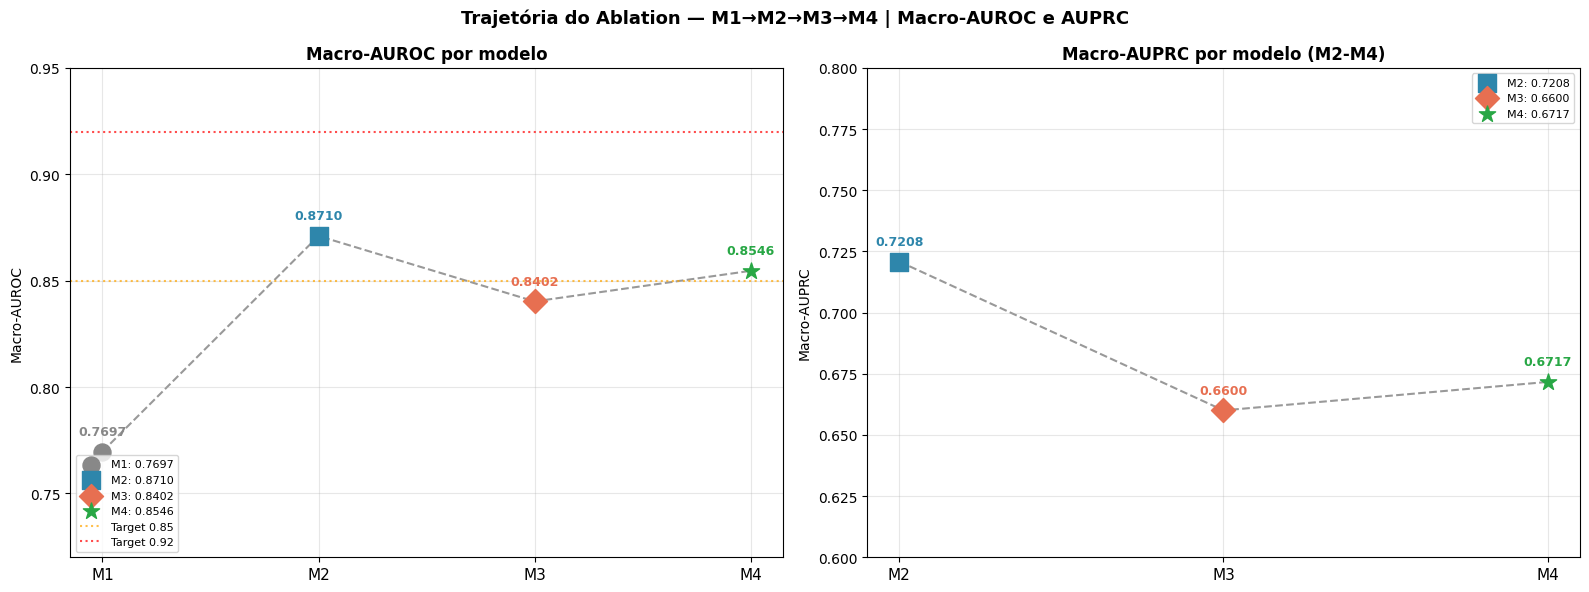

Curva de progresso salva.


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Trajetória do Ablation — M1→M2→M3→M4 | Macro-AUROC e AUPRC',
             fontsize=13, fontweight='bold')

models  = ['M1','M2','M3','M4']
colors  = ['#888888','#2E86AB','#E76F51','#28A745']
markers = ['o','s','D','*']
aurocs  = [m1_res['macro_auroc'],
           metrics_m2['MACRO']['auroc'],
           metrics_m3['MACRO']['auroc'],
           metrics_m4['MACRO']['auroc']]
auprcs  = [None,
           metrics_m2['MACRO']['auprc'],
           metrics_m3['MACRO']['auprc'],
           metrics_m4['MACRO']['auprc']]

# AUROC
ax = axes[0]
ax.plot(range(len(models)), aurocs, 'k--', alpha=0.4, zorder=1)
for i,(m,a,c,mk) in enumerate(zip(models,aurocs,colors,markers)):
    ax.scatter(i, a, color=c, s=150, marker=mk, zorder=3, label=f'{m}: {a:.4f}')
    ax.annotate(f'{a:.4f}', (i,a), textcoords='offset points',
                xytext=(0,12), ha='center', fontsize=9, fontweight='bold', color=c)
ax.axhline(y=0.85, color='orange', linestyle=':', alpha=0.7, label='Target 0.85')
ax.axhline(y=0.92, color='red', linestyle=':', alpha=0.7, label='Target 0.92')
ax.set_xticks(range(len(models))); ax.set_xticklabels(models, fontsize=11)
ax.set_ylabel('Macro-AUROC'); ax.set_title('Macro-AUROC por modelo', fontweight='bold')
ax.set_ylim(0.72, 0.95); ax.legend(fontsize=8); ax.grid(alpha=0.3)

# AUPRC (M2-M4)
ax = axes[1]
auprcs_plot = [v for v in auprcs if v is not None]
models_plot = ['M2','M3','M4']
colors_plot = [colors[1],colors[2],colors[3]]
ax.plot(range(len(models_plot)), auprcs_plot, 'k--', alpha=0.4, zorder=1)
for i,(m,a,c,mk) in enumerate(zip(models_plot,auprcs_plot,colors_plot,markers[1:])):
    ax.scatter(i, a, color=c, s=150, marker=mk, zorder=3, label=f'{m}: {a:.4f}')
    ax.annotate(f'{a:.4f}', (i,a), textcoords='offset points',
                xytext=(0,12), ha='center', fontsize=9, fontweight='bold', color=c)
ax.set_xticks(range(len(models_plot))); ax.set_xticklabels(models_plot, fontsize=11)
ax.set_ylabel('Macro-AUPRC'); ax.set_title('Macro-AUPRC por modelo (M2-M4)', fontweight='bold')
ax.set_ylim(0.60, 0.80); ax.legend(fontsize=8); ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(f'{OUT_DIR}/ablation_progress.png', dpi=150, bbox_inches='tight')
plt.show()
print('Curva de progresso salva.')

## SEÇÃO 5 — Heatmap de AUROC por Label

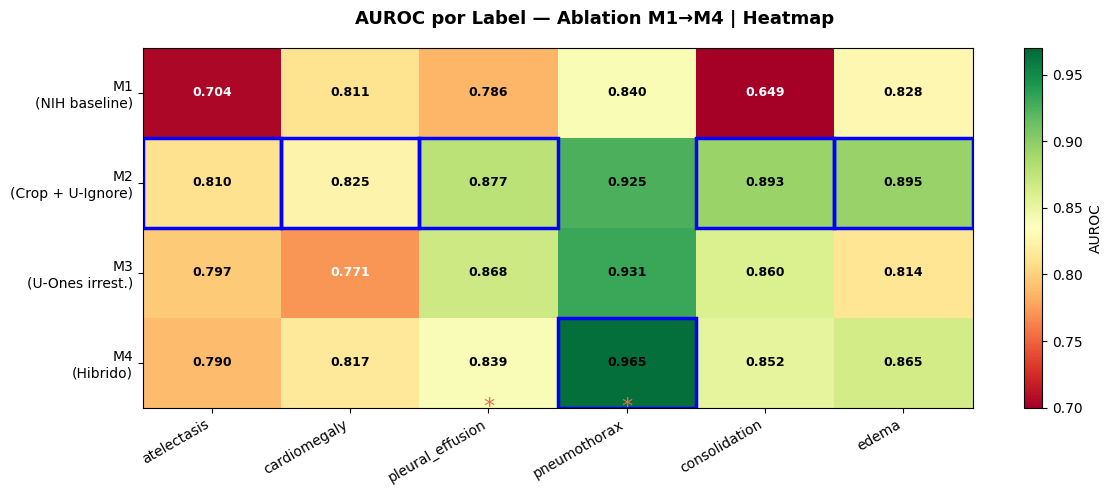

Heatmap salvo. (* = U-Ones no M4 | Azul = melhor por label)


In [ ]:
fig, ax = plt.subplots(figsize=(12, 5))
fig.suptitle('AUROC por Label — Ablation M1→M4 | Heatmap',
             fontsize=13, fontweight='bold')

data = np.array([
    [m1_res['per_label_auroc'].get(lbl, 0) for lbl in LABELS],
    [metrics_m2[lbl]['auroc'] or 0 for lbl in LABELS],
    [metrics_m3[lbl]['auroc'] or 0 for lbl in LABELS],
    [metrics_m4[lbl]['auroc'] or 0 for lbl in LABELS],
])
model_names = [
    'M1\n(NIH baseline)',
    'M2\n(Crop + U-Ignore)',
    'M3\n(U-Ones irrest.)',
    'M4\n(Hibrido)',
]

im = ax.imshow(data, cmap='RdYlGn', vmin=0.70, vmax=0.97, aspect='auto')
ax.set_xticks(range(N_LABELS))
ax.set_xticklabels(LABELS, rotation=30, ha='right', fontsize=10)
ax.set_yticks(range(4))
ax.set_yticklabels(model_names, fontsize=10)
plt.colorbar(im, ax=ax, label='AUROC')

for i in range(4):
    for j in range(N_LABELS):
        val = data[i, j]
        color = 'white' if val < 0.78 else 'black'
        ax.text(j, i, f'{val:.3f}', ha='center', va='center',
                fontsize=9, fontweight='bold', color=color)

# Marca o melhor por label
for j in range(N_LABELS):
    best_i = np.argmax(data[:, j])
    ax.add_patch(plt.Rectangle((j - 0.5, best_i - 0.5), 1, 1,
                 fill=False, edgecolor='blue', linewidth=2.5))

# Marca U-Ones labels no M4
for j, lbl in enumerate(LABELS):
    if lbl in UONES_LABELS:
        ax.text(j, 3.6, '*', ha='center', va='bottom',
                fontsize=16, color='#E76F51')

plt.tight_layout()
plt.savefig(f'{OUT_DIR}/ablation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print('Heatmap salvo. (* = U-Ones no M4 | Azul = melhor por label)')

## SEÇÃO 6 — Curvas ROC Comparativas M2/M3/M4

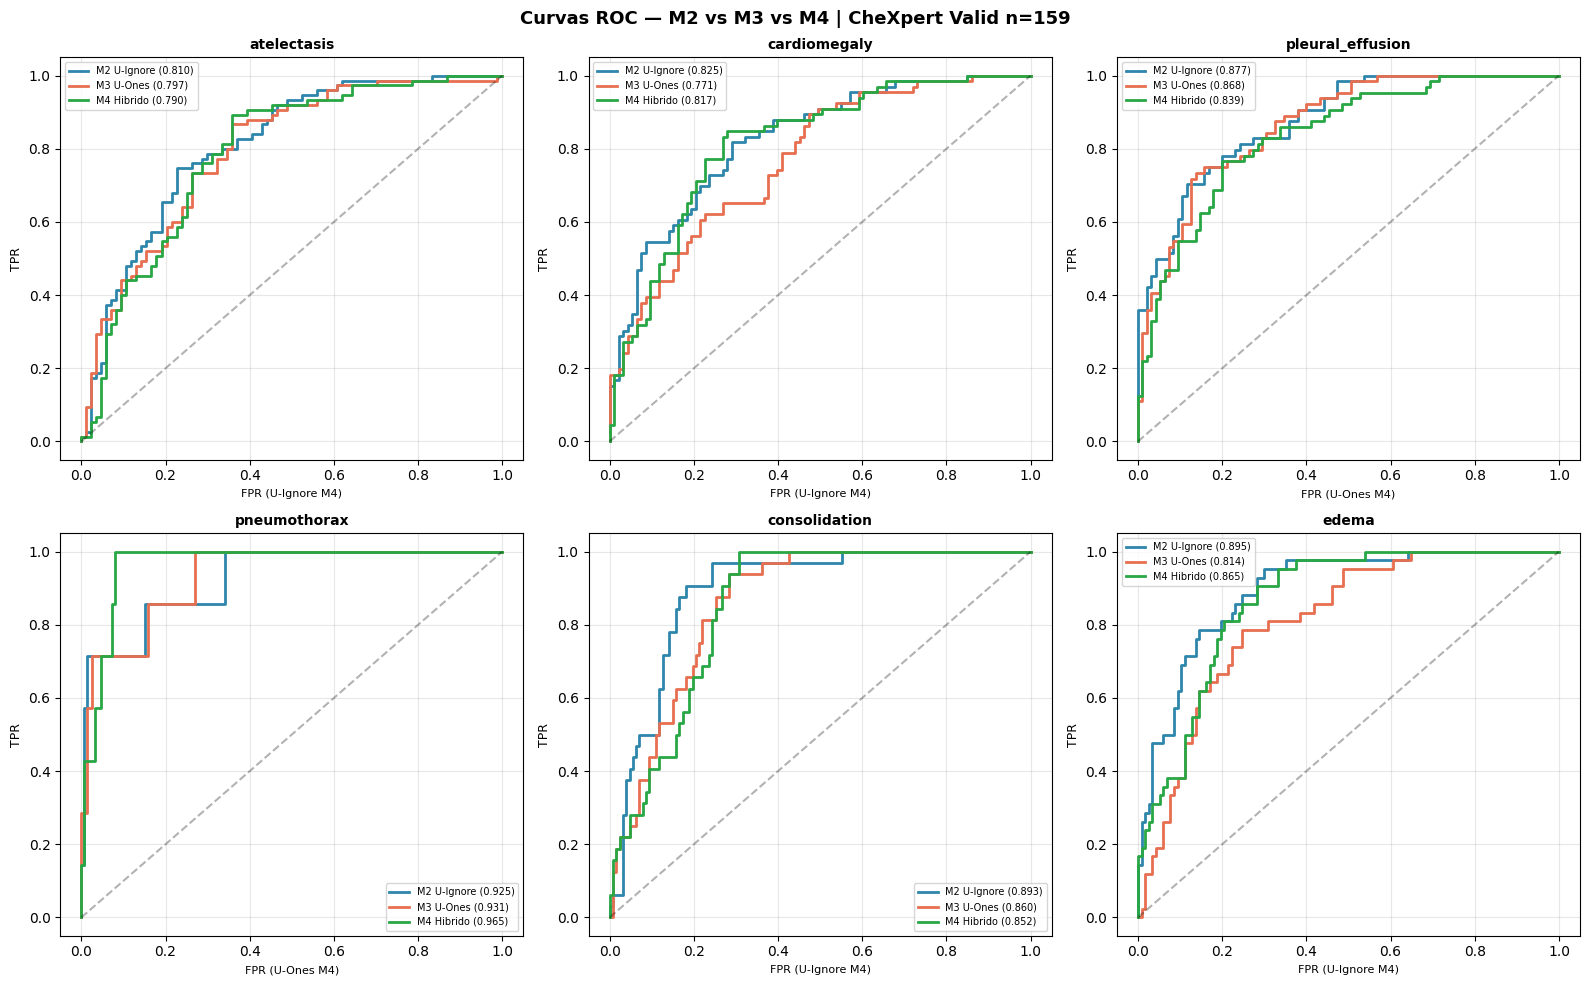

ROC curves salvas.


In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle('Curvas ROC — M2 vs M3 vs M4 | CheXpert Valid n=159',
             fontsize=13, fontweight='bold')
axes = axes.flatten()
colors4 = {'M2 U-Ignore':'#2E86AB','M3 U-Ones':'#E76F51','M4 Híbrido':'#28A745'}

for i, lbl in enumerate(LABELS):
    ax = axes[i]
    yt = y_true[:, i]
    if len(np.unique(yt)) < 2: continue
    for name, yp, color in [('M2 U-Ignore',y_pred_m2[:,i],'#2E86AB'),
                              ('M3 U-Ones',  y_pred_m3[:,i],'#E76F51'),
                              ('M4 Hibrido', y_pred_m4[:,i],'#28A745')]:
        fpr,tpr,_ = roc_curve(yt,yp)
        auc = roc_auc_score(yt,yp)
        ax.plot(fpr,tpr,color=color,lw=2,label=f'{name} ({auc:.3f})')
    ax.plot([0,1],[0,1],'k--',alpha=0.3)
    ax.set_title(lbl, fontweight='bold', fontsize=10)
    pol = '(U-Ones M4)' if lbl in UONES_LABELS else '(U-Ignore M4)'
    ax.set_xlabel(f'FPR {pol}', fontsize=8)
    ax.set_ylabel('TPR', fontsize=9)
    ax.legend(fontsize=7); ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(f'{OUT_DIR}/roc_m2_m3_m4.png', dpi=150, bbox_inches='tight')
plt.show()
print('ROC curves salvas.')

## SEÇÃO 7 — Comparativo de Métricas Operacionais

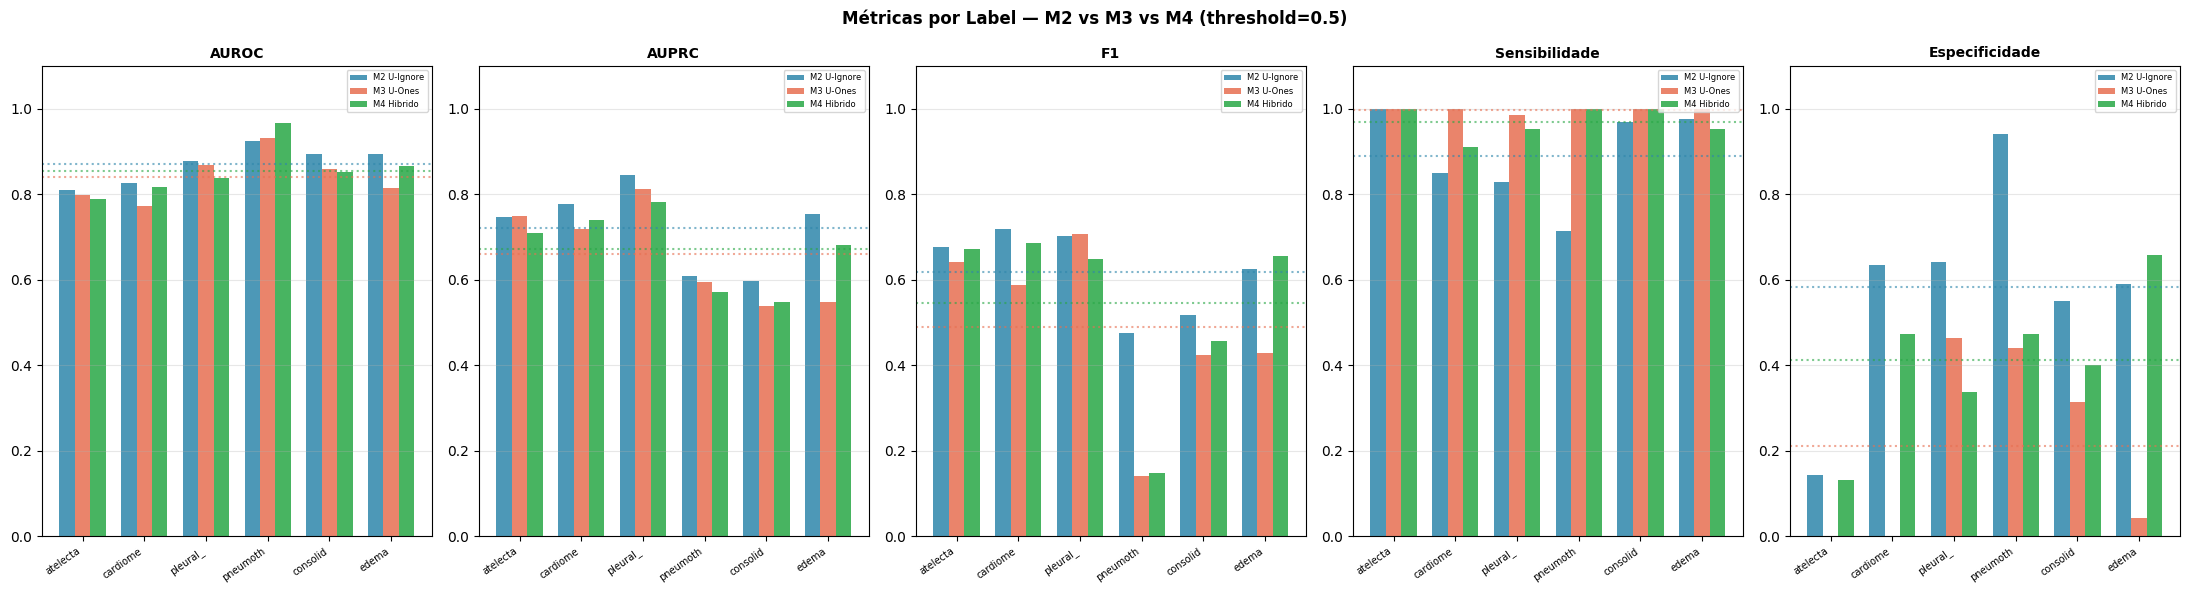

Verde = M4 Híbrido | Linhas pontilhadas = macro de cada modelo


In [ ]:
metrics_list  = ['auroc','auprc','f1','sensitivity','specificity']
metric_labels = ['AUROC','AUPRC','F1','Sensibilidade','Especificidade']

fig, axes = plt.subplots(1, len(metrics_list), figsize=(22, 6))
fig.suptitle('Métricas por Label — M2 vs M3 vs M4 (threshold=0.5)',
             fontsize=12, fontweight='bold')

x = np.arange(N_LABELS); width = 0.25
colors3 = ['#2E86AB','#E76F51','#28A745']

for ax, metric, mlbl in zip(axes, metrics_list, metric_labels):
    v2 = [metrics_m2[lbl][metric] or 0 for lbl in LABELS]
    v3 = [metrics_m3[lbl][metric] or 0 for lbl in LABELS]
    v4 = [metrics_m4[lbl][metric] or 0 for lbl in LABELS]

    ax.bar(x-width, v2, width, label='M2 U-Ignore', color='#2E86AB', alpha=0.85)
    ax.bar(x,       v3, width, label='M3 U-Ones',   color='#E76F51', alpha=0.85)
    ax.bar(x+width, v4, width, label='M4 Hibrido',  color='#28A745', alpha=0.85)

    ax.set_title(mlbl, fontweight='bold', fontsize=10)
    ax.set_xticks(x)
    ax.set_xticklabels([l[:8] for l in LABELS], rotation=35, ha='right', fontsize=7)
    ax.set_ylim(0, 1.1); ax.legend(fontsize=6); ax.grid(axis='y', alpha=0.3)
    for m, vals, color in [('M2',v2,'#2E86AB'),('M3',v3,'#E76F51'),('M4',v4,'#28A745')]:
        mac = metrics_m2['MACRO'][metric] if m=='M2' else (
              metrics_m3['MACRO'][metric] if m=='M3' else metrics_m4['MACRO'][metric])
        if mac: ax.axhline(y=mac or 0, color=color, linestyle=':', alpha=0.6)

plt.tight_layout()
plt.savefig(f'{OUT_DIR}/metrics_m2_m3_m4.png', dpi=150, bbox_inches='tight')
plt.show()
print('Verde = M4 Híbrido | Linhas pontilhadas = macro de cada modelo')

## SEÇÃO 8 — DeLong: M4 vs M2 (melhor vs referência)

In [ ]:
def delong_roc_variance(ground_truth, predictions):
    order=np.argsort(-predictions)
    n1=int(ground_truth.sum()); n0=len(ground_truth)-n1
    ol=ground_truth[order]
    tp=np.cumsum(ol); fp=np.cumsum(1-ol)
    auc=np.trapz(tp/n1,fp/n0)
    pi=np.where(ground_truth==1)[0]; ni=np.where(ground_truth==0)[0]
    v10=np.zeros(n1); v01=np.zeros(n0)
    for i,pi_ in enumerate(pi):
        v10[i]=np.mean(predictions[pi_]>predictions[ni])+0.5*np.mean(predictions[pi_]==predictions[ni])
    for j,nj in enumerate(ni):
        v01[j]=np.mean(predictions[pi]>predictions[nj])+0.5*np.mean(predictions[pi]==predictions[nj])
    return auc, np.var(v10)/n1+np.var(v01)/n0

print('Teste DeLong — M4 Híbrido vs M2 U-Ignore (referência)')
print(f'\n{"Label":<22} {"M2":>7} {"M4":>7} {"Δ":>8} {"z":>7} {"p":>9} {"Sig":>5} {"Política M4":>12}')
print('-'*80)
delong_m4_m2 = {}
for i, lbl in enumerate(LABELS):
    yt=y_true[:,i]
    if len(np.unique(yt))<2: continue
    a2,v2=delong_roc_variance(yt,y_pred_m2[:,i])
    a4,v4=delong_roc_variance(yt,y_pred_m4[:,i])
    se=np.sqrt(v2+v4)
    z=(a4-a2)/(se+1e-12); p=2*(1-stats.norm.cdf(abs(z)))
    sig='***' if p<0.001 else '**' if p<0.01 else '*' if p<0.05 else 'ns'
    pol='U-Ones' if lbl in UONES_LABELS else 'U-Ignore'
    delong_m4_m2[lbl]={'a2':a2,'a4':a4,'z':z,'p':p,'sig':sig}
    print(f'{lbl:<22} {a2:>7.4f} {a4:>7.4f} {a4-a2:>+8.4f} {z:>7.3f} {p:>9.4f} {sig:>5} {pol:>12}')
print('\n* p<0.05  ** p<0.01  *** p<0.001  ns=não significativo | n=159')

Teste DeLong — M4 Híbrido vs M2 U-Ignore (referência)

Label                       M2      M4        Δ       z         p   Sig  Política M4
--------------------------------------------------------------------------------
atelectasis             0.8103  0.7895  -0.0208  -0.421    0.6737    ns     U-Ignore
cardiomegaly            0.8254  0.8167  -0.0086  -0.185    0.8529    ns     U-Ignore
pleural_effusion        0.8775  0.8388  -0.0387  -0.954    0.3400    ns       U-Ones
pneumothorax            0.9248  0.9652  +0.0404   0.826    0.4091    ns       U-Ones
consolidation           0.8932  0.8521  -0.0411  -1.040    0.2981    ns     U-Ignore
edema                   0.8948  0.8653  -0.0295  -0.776    0.4380    ns     U-Ignore

* p<0.05  ** p<0.01  *** p<0.001  ns=não significativo | n=159


## SEÇÃO 8.5 — Grad-CAM Comparativo M2 / M3 / M4

In [ ]:
# ── Grad-CAM ─────────────────────────────────────────────────────────────────
def get_gradcam(model, img_tensor, class_idx, last_conv_layer_name=None):
    """Grad-CAM — busca block14_sepconv2_act por nome com fallback."""
    if last_conv_layer_name is None:
        for name in ['block14_sepconv2_act','block14_sepconv2_bn',
                     'block14_sepconv1_act','block13_sepconv2_act']:
            try:
                model.get_layer(name)
                last_conv_layer_name = name
                break
            except ValueError:
                continue
        if last_conv_layer_name is None:
            for layer in reversed(model.layers):
                if (hasattr(layer,'output_shape') and
                    isinstance(layer.output_shape,tuple) and
                    len(layer.output_shape)==4 and
                    'dense'   not in layer.name.lower() and
                    'dropout' not in layer.name.lower()):
                    last_conv_layer_name = layer.name
                    break
    if last_conv_layer_name is None:
        raise ValueError('Nenhuma camada conv encontrada')

    grad_model = tf.keras.Model(
        inputs=model.input,
        outputs=[model.get_layer(last_conv_layer_name).output, model.output]
    )
    with tf.GradientTape() as tape:
        img_batch = tf.expand_dims(img_tensor, 0)
        conv_out, preds = grad_model(img_batch)
        loss = preds[:, class_idx]

    grads        = tape.gradient(loss, conv_out)
    pooled_grads = tf.reduce_mean(grads, axis=(0,1,2))
    heatmap      = conv_out[0] @ pooled_grads[..., tf.newaxis]
    heatmap      = tf.squeeze(heatmap)
    heatmap      = tf.maximum(heatmap, 0) / (tf.math.reduce_max(heatmap) + 1e-7)
    return heatmap.numpy(), float(preds[0, class_idx])

# ── Grad-CAM++ ────────────────────────────────────────────────────────────────
def get_gradcam_pp(model, img_tensor, class_idx, layer_name=None):
    """
    Grad-CAM++ (Chattopadhay et al., 2018).
    Pesa cada posição espacial com alpha = grad^2 / (2*grad^2 + A*grad^3)
    onde A = soma espacial das ativações.
    Melhora localização de múltiplos objetos/regiões e ativações bilaterais.
    """
    if layer_name is None:
        for name in ['block14_sepconv2_act','block14_sepconv2_bn',
                     'block14_sepconv1_act','block13_sepconv2_act']:
            try: model.get_layer(name); layer_name=name; break
            except ValueError: continue
    grad_model = tf.keras.Model(
        inputs=model.input,
        outputs=[model.get_layer(layer_name).output, model.output])
    with tf.GradientTape() as tape:
        conv_out, preds = grad_model(tf.expand_dims(img_tensor,0))
        loss = preds[:, class_idx]
    grads   = tape.gradient(loss, conv_out)   # (1,H,W,C)
    grads   = grads[0]                         # (H,W,C)
    acts    = conv_out[0]                      # (H,W,C)

    grad2   = grads**2
    grad3   = grads**3
    # soma espacial das ativações por canal: (1,1,C)
    A_sum   = tf.reduce_sum(acts, axis=(0,1), keepdims=True)
    alpha   = grad2 / (2*grad2 + A_sum*grad3 + 1e-7)
    # pondera apenas gradientes positivos (ReLU)
    weights = tf.reduce_sum(alpha * tf.nn.relu(grads), axis=(0,1))  # (C,)
    heatmap = acts @ weights[...,tf.newaxis]   # (H,W,1)
    heatmap = tf.squeeze(heatmap)
    heatmap = tf.maximum(heatmap,0)/(tf.math.reduce_max(heatmap)+1e-7)
    return heatmap.numpy(), float(preds[0,class_idx])

# ── Overlay ───────────────────────────────────────────────────────────────────
def overlay_gradcam(img_path, heatmap, alpha=0.4):
    img     = PILImage.open(img_path).convert('L').resize((IMG_SIZE, IMG_SIZE))
    img_rgb = np.stack([np.array(img)] * 3, axis=-1)
    hm_res  = np.array(PILImage.fromarray((heatmap*255).astype(np.uint8)).resize((IMG_SIZE,IMG_SIZE)))
    hm_col  = plt.cm.jet(hm_res / 255.0)[:,:,:3] * 255
    return (img_rgb*(1-alpha) + hm_col*alpha).astype(np.uint8), img_rgb


def preprocess_image(img_path):
    img = PILImage.open(img_path).convert('L').resize((IMG_SIZE, IMG_SIZE))
    img = np.array(img, dtype=np.float32) / 255.0
    img = (img - 0.5056) / 0.2520
    img = np.stack([img, img, img], axis=-1)
    return tf.constant(img, dtype=tf.float32)

# ── Painel Grad-CAM vs Grad-CAM++ (sem MedSAM) ───────────────────────────────
def gradcam_comparison_panel(img_path, labels, y_true_row=None,
                              models_dict=None, top_label_idx=None):
    """
    Painel comparativo Grad-CAM vs Grad-CAM++ por modelo.
    Layout:
      Linha 0: Imagem original | Prob M2 | Prob M3 | Prob M4
      Linha 1: Ref (label alvo)| GradCAM M2 | GradCAM M3 | GradCAM M4
      Linha 2: Ref             | GradCAM++ M2 | GradCAM++ M3 | GradCAM++ M4
    """
    if models_dict is None:
        models_dict = {'M2 U-Ignore':model_m2,'M3 U-Ones':model_m3,'M4 Hibrido':model_m4}

    img_tensor = preprocess_image(img_path)
    preds = {name: m(tf.expand_dims(img_tensor,0),training=False).numpy()[0]
             for name,m in models_dict.items()}

    if top_label_idx is None:
        top_label_idx = int(np.argmax(np.mean([p for p in preds.values()],axis=0)))

    top_lbl      = labels[top_label_idx]
    n_models     = len(models_dict)
    model_colors = {'M2 U-Ignore':'#2E86AB','M3 U-Ones':'#E76F51','M4 Hibrido':'#28A745'}
    raw = np.array(PILImage.open(img_path).convert('L').resize((IMG_SIZE,IMG_SIZE)))

    fig = plt.figure(figsize=(5*(n_models+1), 15))
    gs  = gridspec.GridSpec(3, n_models+1, figure=fig, hspace=0.4, wspace=0.25)

    # ── Linha 0: Imagem + barras ──────────────────────────────────────────────
    ax = fig.add_subplot(gs[0,0])
    ax.imshow(raw, cmap='gray')
    if y_true_row is not None:
        pos = [labels[j] for j in range(len(labels)) if y_true_row[j]==1]
        ax.set_title(f'Imagem Original\nGT: {pos}', fontweight='bold', fontsize=8)
    else:
        ax.set_title('Imagem Original', fontweight='bold', fontsize=9)
    ax.axis('off')

    y_pos = np.arange(len(labels))
    for ci, (mname, pred) in enumerate(preds.items()):
        ax = fig.add_subplot(gs[0, ci+1])
        color = model_colors.get(mname,'#888')
        ax.barh(y_pos, pred, color=color, alpha=0.85)
        ax.axvline(x=0.5, color='red', linestyle='--', alpha=0.5)
        if y_true_row is not None:
            for j,gt in enumerate(y_true_row):
                if gt==1: ax.axhline(y=j,color='green',linestyle=':',alpha=0.5,lw=1.5)
        ax.set_yticks(y_pos); ax.set_yticklabels(labels,fontsize=7)
        ax.set_xlim(0,1); ax.set_title(mname,fontweight='bold',fontsize=8,color=color)
        ax.grid(axis='x',alpha=0.3)
        for j,p in enumerate(pred):
            ax.text(min(p+0.02,0.95),j,f'{p:.2f}',va='center',fontsize=6,
                    color='darkblue' if p>0.5 else 'gray')

    # ── Linha 1: Grad-CAM ─────────────────────────────────────────────────────
    ax = fig.add_subplot(gs[1,0])
    ax.imshow(raw, cmap='gray')
    ax.set_title(f'Label alvo:\n{top_lbl}\n(Grad-CAM)', fontweight='bold', fontsize=9)
    ax.axis('off')

    for ci, (mname, model) in enumerate(models_dict.items()):
        ax    = fig.add_subplot(gs[1, ci+1])
        color = model_colors.get(mname,'#888')
        hm, conf = get_gradcam(model, img_tensor, top_label_idx)
        ov, _    = overlay_gradcam(img_path, hm)
        ax.imshow(ov)
        ax.set_title(f'Grad-CAM\n{mname}\n{top_lbl} p={conf:.2f}',
                     fontweight='bold', fontsize=7, color=color)
        ax.axis('off')

    # ── Linha 2: Grad-CAM++ ───────────────────────────────────────────────────
    ax = fig.add_subplot(gs[2,0])
    ax.imshow(raw, cmap='gray')
    ax.set_title(f'Label alvo:\n{top_lbl}\n(Grad-CAM++)', fontweight='bold', fontsize=9)
    ax.axis('off')

    for ci, (mname, model) in enumerate(models_dict.items()):
        ax    = fig.add_subplot(gs[2, ci+1])
        color = model_colors.get(mname,'#888')
        hm_pp, conf_pp = get_gradcam_pp(model, img_tensor, top_label_idx)
        ov_pp, _       = overlay_gradcam(img_path, hm_pp)
        ax.imshow(ov_pp)
        ax.set_title(f'Grad-CAM++\n{mname}\n{top_lbl} p={conf_pp:.2f}',
                     fontweight='bold', fontsize=7, color=color)
        ax.axis('off')

    fig.suptitle(img_path.split('/')[-1], fontsize=9, y=1.01)
    plt.tight_layout(); plt.show()

    # Tabela
    print(f'  {"Label":<22}', end='')
    for mname in preds: print(f' {mname[:8]:>9}', end='')
    if y_true_row is not None: print(f' {"GT":>4}', end='')
    print()
    print('  '+'-'*(22+10*len(preds)+5))
    for j,lbl in enumerate(labels):
        print(f'  {lbl:<22}', end='')
        for pred in preds.values(): print(f' {pred[j]:>9.3f}', end='')
        if y_true_row is not None:
            print(f' {"+1" if y_true_row[j]==1 else " 0":>4}', end='')
        print()
    return preds


print('Grad-CAM e Grad-CAM++ definidos.')
print('Diferenca principal: Grad-CAM++ pondera posicoes espaciais via alpha,')
print('capturando melhor multiplas regioes ativas (ex: edema bilateral).')

Grad-CAM e Grad-CAM++ definidos.
Diferenca principal: Grad-CAM++ pondera posicoes espaciais via alpha,
capturando melhor multiplas regioes ativas (ex: edema bilateral).


=== Pneumothorax — Grad-CAM vs Grad-CAM++ ===


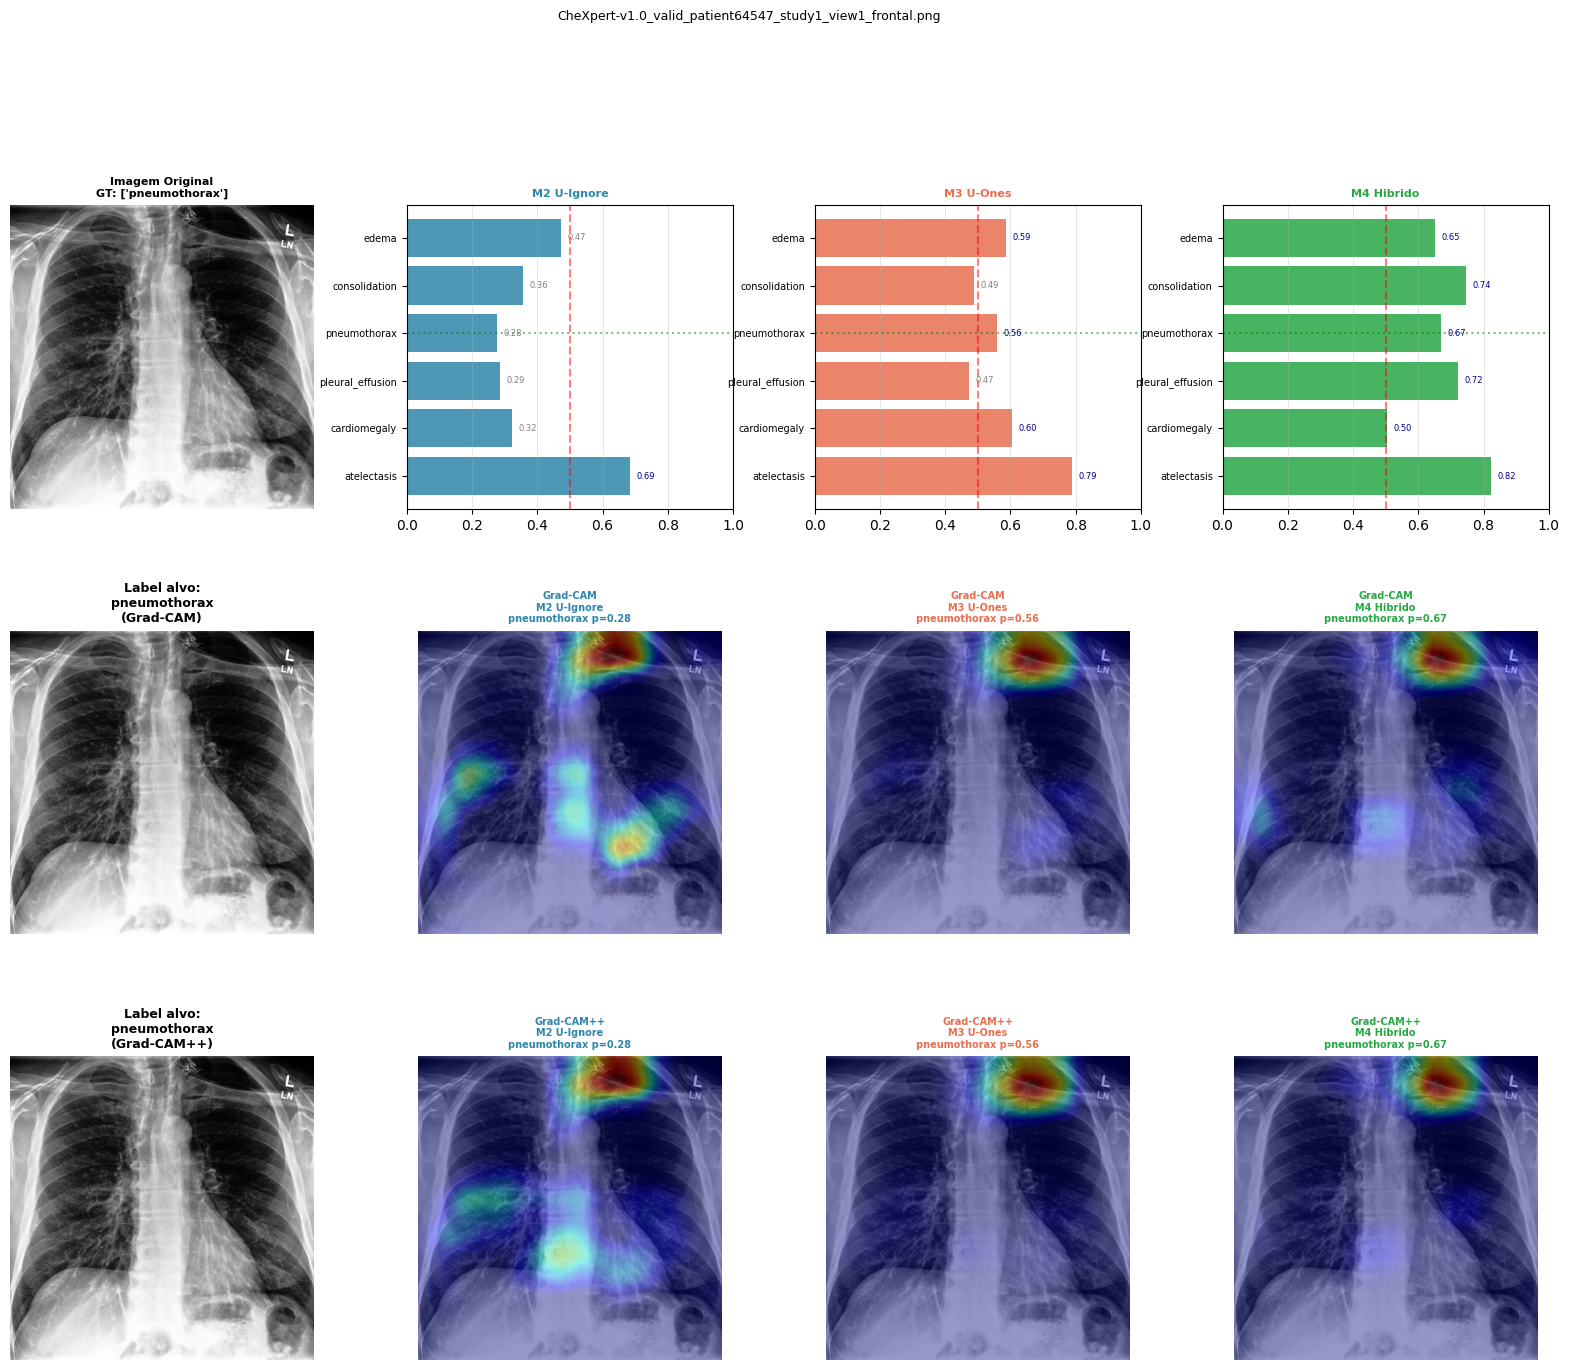

  Label                   M2 U-Ign  M3 U-One  M4 Hibri   GT
  ---------------------------------------------------------
  atelectasis                0.685     0.788     0.824    0
  cardiomegaly               0.323     0.604     0.503    0
  pleural_effusion           0.287     0.474     0.721    0
  pneumothorax               0.276     0.558     0.669   +1
  consolidation              0.358     0.487     0.745    0
  edema                      0.472     0.585     0.652    0

=== Edema — Grad-CAM vs Grad-CAM++ (patologia bilateral) ===


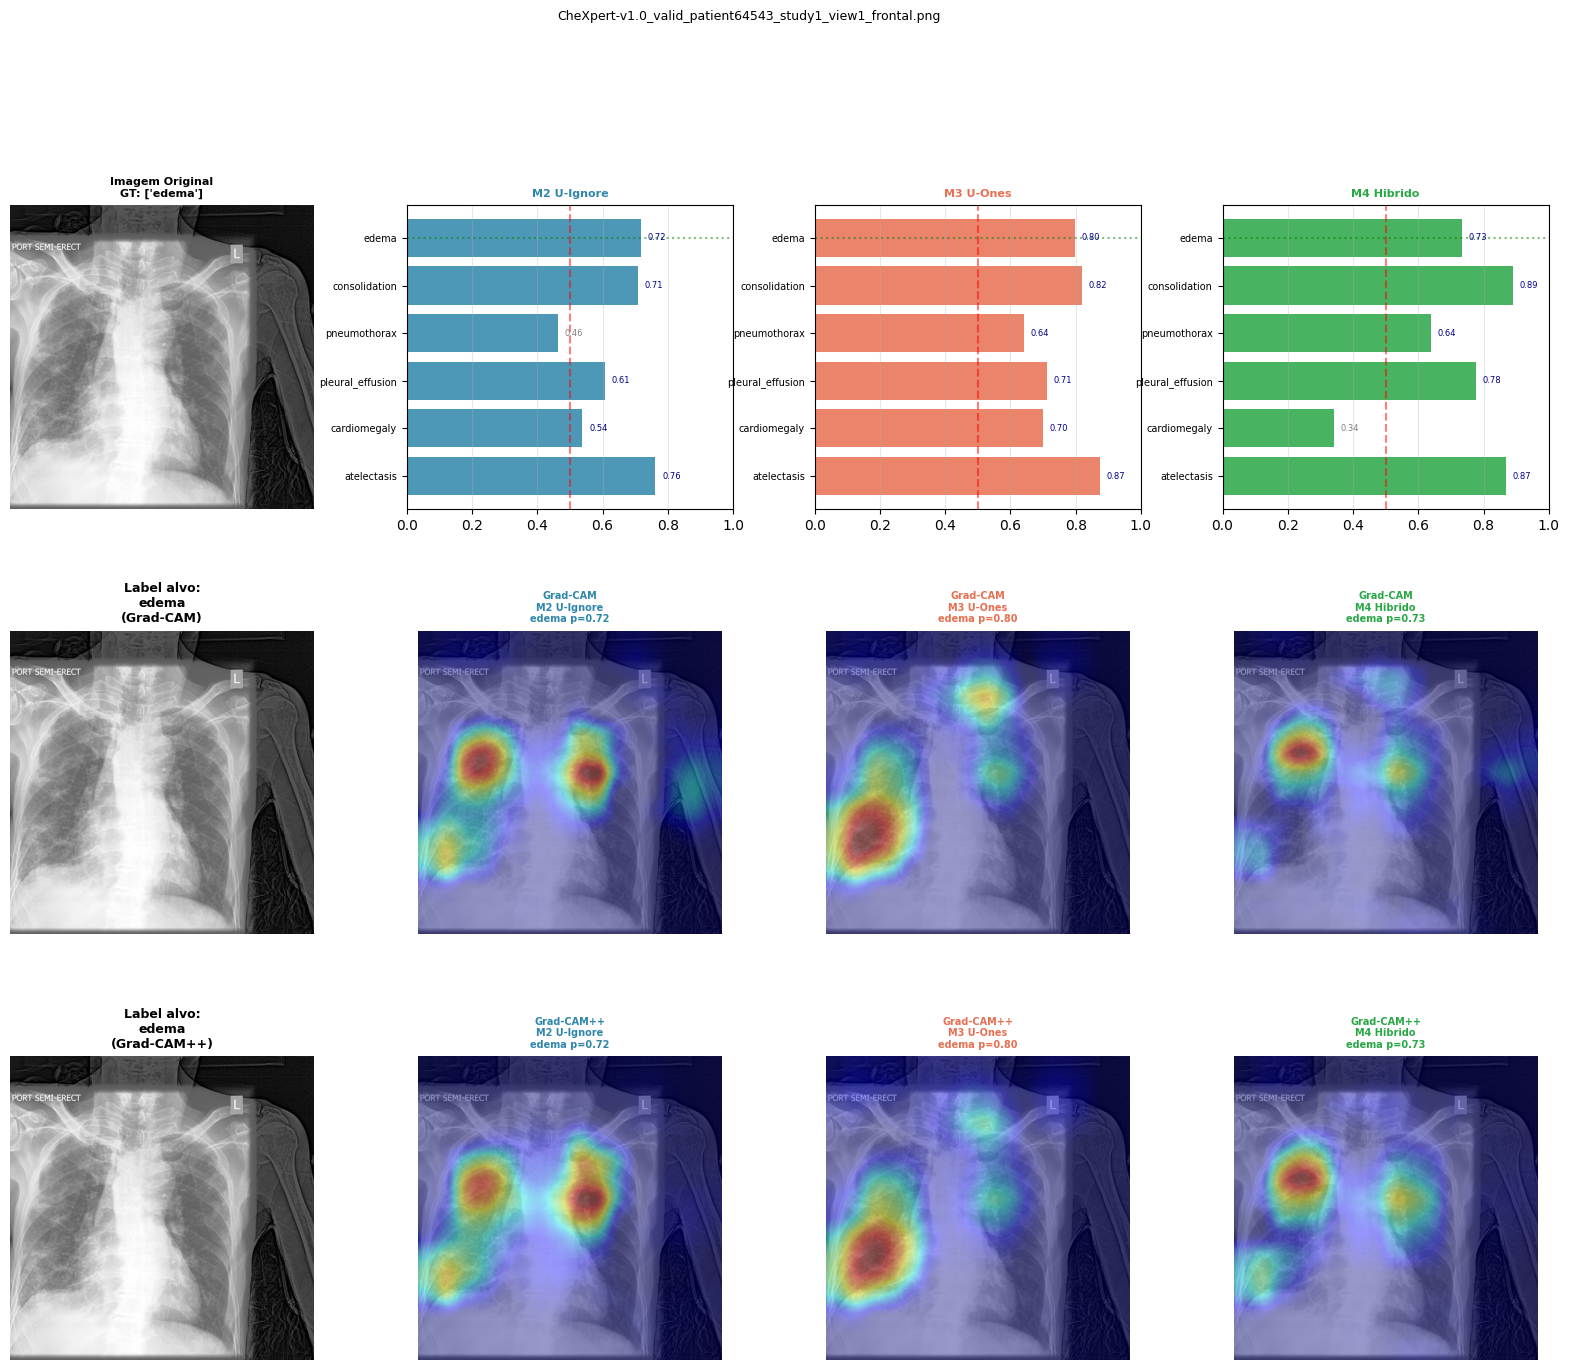

  Label                   M2 U-Ign  M3 U-One  M4 Hibri   GT
  ---------------------------------------------------------
  atelectasis                0.762     0.874     0.869    0
  cardiomegaly               0.539     0.701     0.342    0
  pleural_effusion           0.609     0.713     0.776    0
  pneumothorax               0.464     0.643     0.637    0
  consolidation              0.708     0.820     0.891    0
  edema                      0.719     0.798     0.733   +1

=== Pleural Effusion — Grad-CAM vs Grad-CAM++ ===


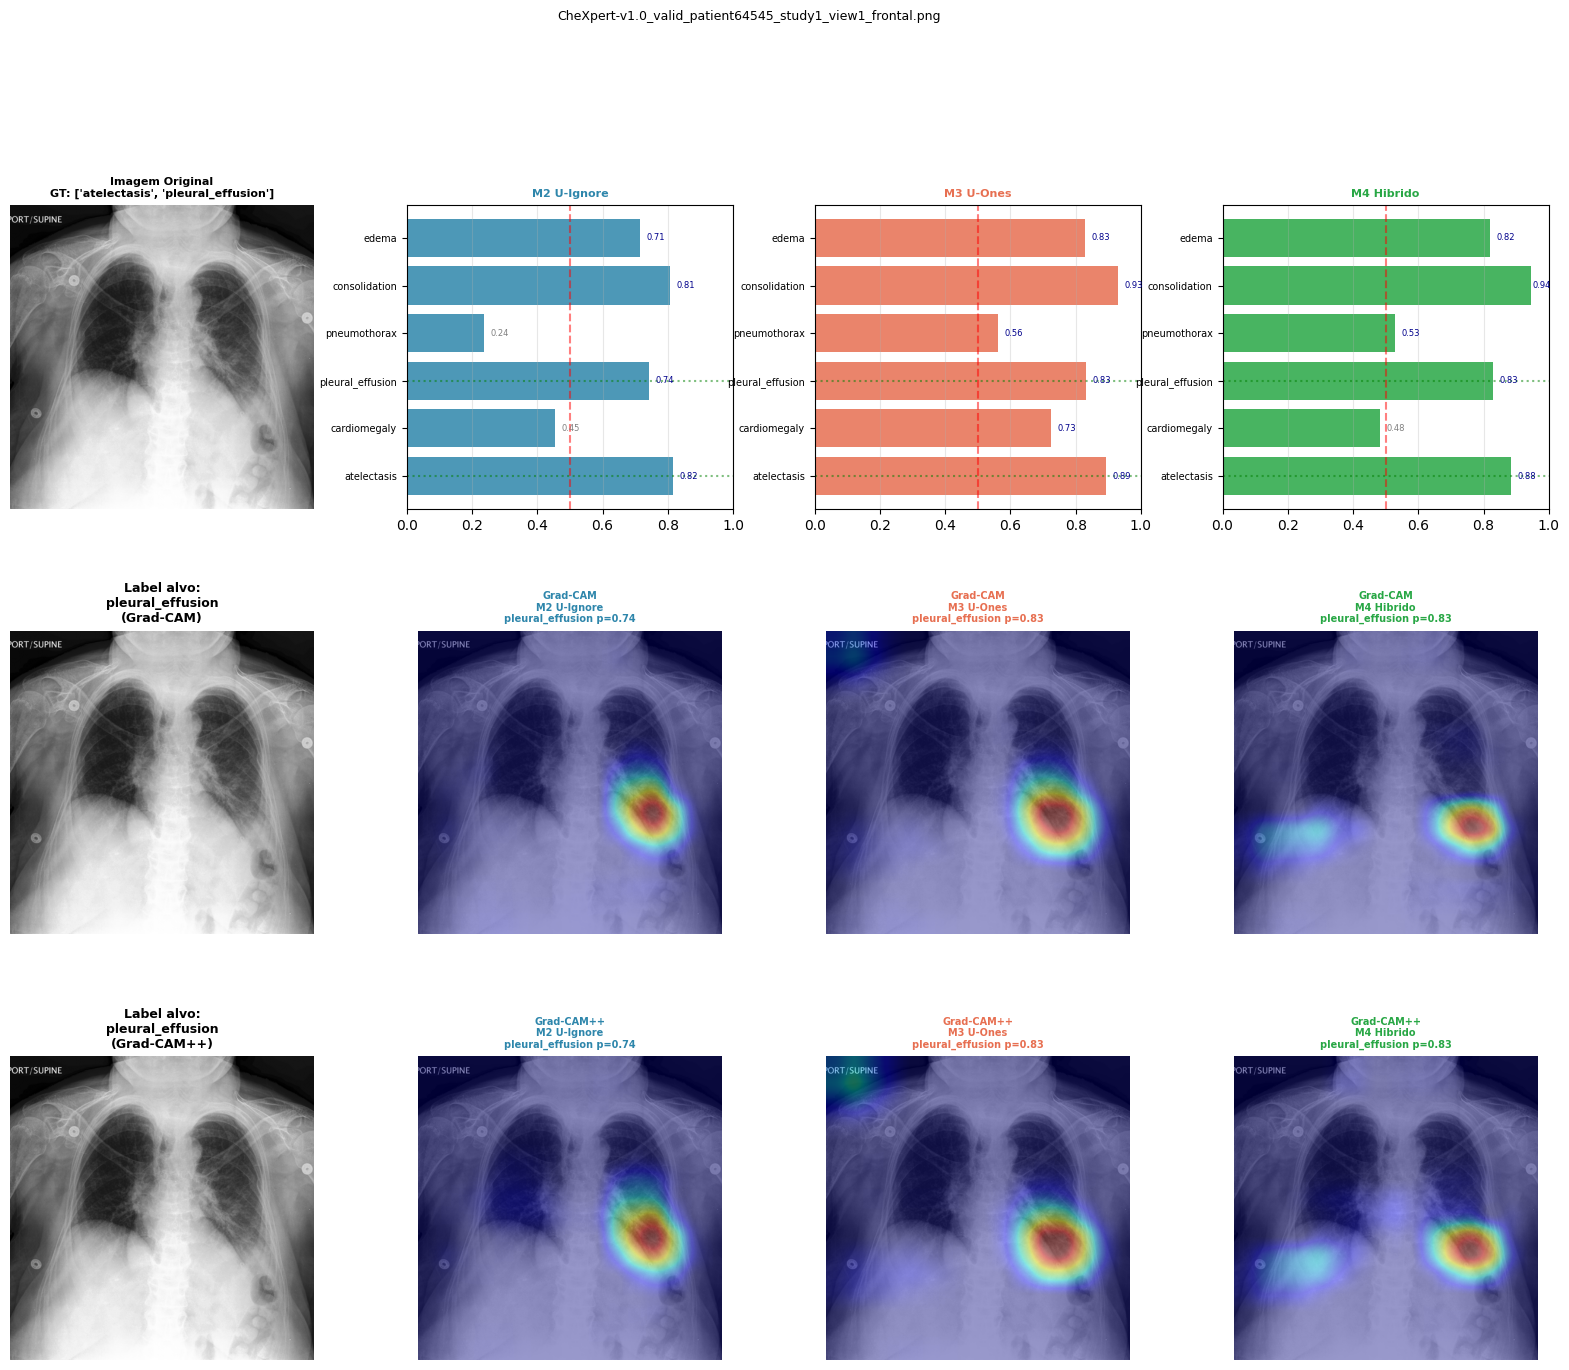

  Label                   M2 U-Ign  M3 U-One  M4 Hibri   GT
  ---------------------------------------------------------
  atelectasis                0.815     0.894     0.884   +1
  cardiomegaly               0.454     0.725     0.483    0
  pleural_effusion           0.743     0.831     0.830   +1
  pneumothorax               0.236     0.562     0.529    0
  consolidation              0.806     0.929     0.944    0
  edema                      0.714     0.829     0.819    0

=== Multi-label ===


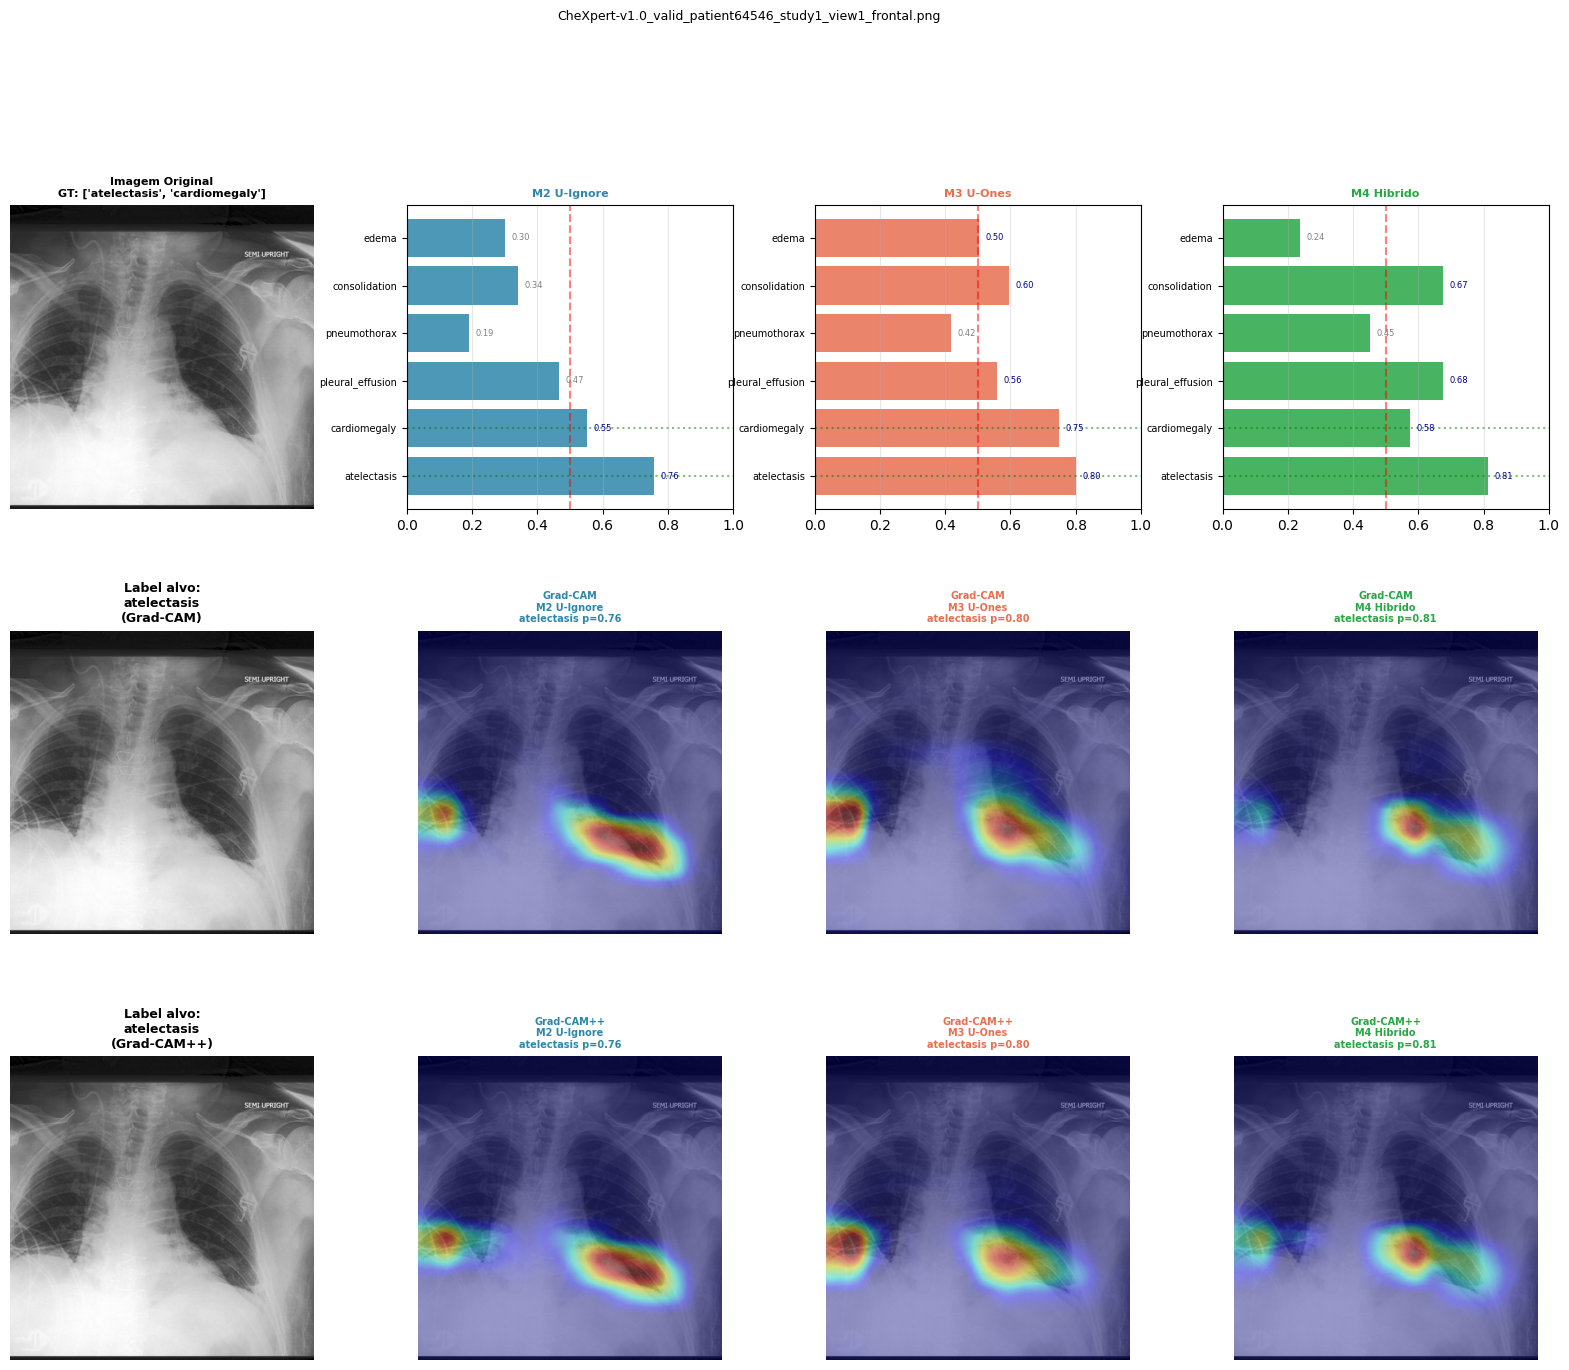

  Label                   M2 U-Ign  M3 U-One  M4 Hibri   GT
  ---------------------------------------------------------
  atelectasis                0.758     0.802     0.814   +1
  cardiomegaly               0.552     0.748     0.576   +1
  pleural_effusion           0.467     0.559     0.677    0
  pneumothorax               0.190     0.416     0.453    0
  consolidation              0.341     0.596     0.674    0
  edema                      0.300     0.504     0.239    0


In [ ]:
df_valid['n_pos'] = df_valid[LABELS].sum(axis=1)
y_true = df_valid[LABELS].values.astype(np.float32)
models_dict = {'M2 U-Ignore':model_m2,'M3 U-Ones':model_m3,'M4 Hibrido':model_m4}

pneumo_idx   = df_valid[df_valid['pneumothorax']==1].index.tolist()
edema_idx    = df_valid[df_valid['edema']==1].index.tolist()
effusion_idx = df_valid[df_valid['pleural_effusion']==1].index.tolist()
multi_idx    = df_valid[df_valid['n_pos']>=2].index.tolist()

if pneumo_idx:
    print('=== Pneumothorax — Grad-CAM vs Grad-CAM++ ===')
    idx = pneumo_idx[0]
    gradcam_comparison_panel(df_valid.loc[idx,'img_path'], LABELS,
                              y_true[idx], models_dict,
                              top_label_idx=LABELS.index('pneumothorax'))

if edema_idx:
    print('\n=== Edema — Grad-CAM vs Grad-CAM++ (patologia bilateral) ===')
    idx = edema_idx[0]
    gradcam_comparison_panel(df_valid.loc[idx,'img_path'], LABELS,
                              y_true[idx], models_dict,
                              top_label_idx=LABELS.index('edema'))

if effusion_idx:
    print('\n=== Pleural Effusion — Grad-CAM vs Grad-CAM++ ===')
    idx = effusion_idx[0]
    gradcam_comparison_panel(df_valid.loc[idx,'img_path'], LABELS,
                              y_true[idx], models_dict,
                              top_label_idx=LABELS.index('pleural_effusion'))

if len(multi_idx) > 1:
    print('\n=== Multi-label ===')
    idx = multi_idx[1]
    gradcam_comparison_panel(df_valid.loc[idx,'img_path'], LABELS,
                              y_true[idx], models_dict)

## SEÇÃO 8.7 — MedSAM: Instalação e Carregamento

In [ ]:
from huggingface_hub import hf_hub_download
import shutil, os

# Mirror com SHA256 verificado: 34b34b78c1d18cb8c6bf84cf9c00e135d6d6c965699f3c0e31ef1bc9dcb5be74
path = hf_hub_download(
    repo_id   = "SansuiHan/medical_models",
    filename  = "medsam_vit_b.pth",
    repo_type = "model",
)

# Copia para o Drive
dest = "/content/drive/MyDrive/medsam_vit_b.pth"
shutil.copy(path, dest)
print(f"Tamanho: {os.path.getsize(dest)/1024**2:.0f} MB")

medsam_vit_b.pth:   0%|          | 0.00/375M [00:00<?, ?B/s]

Tamanho: 358 MB


In [ ]:
import os

MEDSAM_CKPT = f'{BASE}/medsam_vit_b.pth'

# 1. Checkpoint existe?
print(f'Checkpoint existe: {os.path.exists(MEDSAM_CKPT)}')
if os.path.exists(MEDSAM_CKPT):
    print(f'Tamanho: {os.path.getsize(MEDSAM_CKPT)/1024**2:.0f} MB')  # deve ser ~375 MB

# 2. segment_anything instalado?
try:
    from segment_anything import sam_model_registry, SamPredictor
    print('segment_anything: OK')
except ImportError as e:
    print(f'segment_anything NAO instalado: {e}')

# 3. torch disponível com GPU?
try:
    import torch
    print(f'torch: {torch.__version__} | CUDA: {torch.cuda.is_available()}')
except ImportError as e:
    print(f'torch NAO disponivel: {e}')

# 4. Tenta carregar o modelo
try:
    sam = sam_model_registry['vit_b'](checkpoint=MEDSAM_CKPT)
    print('sam_model_registry: carregou OK')
except Exception as e:
    print(f'Erro ao carregar modelo: {e}')

Checkpoint existe: True
Tamanho: 358 MB
segment_anything: OK
torch: 2.11.0+cu128 | CUDA: True
sam_model_registry: carregou OK


In [ ]:
# ── Instala MedSAM (só precisa rodar uma vez por sessão) ─────────────────────
!pip install -q git+https://github.com/bowang-lab/MedSAM
!pip install -q torch torchvision --index-url https://download.pytorch.org/whl/cu118

# ── Caminho do checkpoint MedSAM ─────────────────────────────────────────────
# Baixe com: !gdown https://huggingface.co/wanglab/medsam/resolve/main/medsam_vit_b.pth -O {BASE}/medsam_vit_b.pth
MEDSAM_CKPT = f'{BASE}/medsam_vit_b.pth'

MEDSAM_READY = False
medsam_predictor = None

if os.path.exists(MEDSAM_CKPT):
    try:
        import torch
        from segment_anything import sam_model_registry, SamPredictor
        from PIL import ImageFilter as PILFilter

        device = 'cuda' if torch.cuda.is_available() else 'cpu'
        sam = sam_model_registry['vit_b'](checkpoint=MEDSAM_CKPT)
        sam.to(device)
        medsam_predictor = SamPredictor(sam)
        MEDSAM_READY = True
        print(f'MedSAM carregado ({device}): {MEDSAM_CKPT}')
    except Exception as e:
        print(f'MedSAM nao carregado: {e}')
        from PIL import ImageFilter as PILFilter
else:
    try:
        from PIL import ImageFilter as PILFilter
    except ImportError:
        pass
    print(f'Checkpoint nao encontrado: {MEDSAM_CKPT}')
    print('Fallback visual (bounding box) sera usado.')
    print('Para baixar: !gdown https://huggingface.co/wanglab/medsam/resolve/main/medsam_vit_b.pth')

  Preparing metadata (setup.py) ... done
MedSAM carregado (cuda): /content/drive/MyDrive/medsam_vit_b.pth


## SEÇÃO 8.9 — Grad-CAM + MedSAM Comparativo M2 / M3 / M4

In [ ]:
# ── Funções MedSAM ───────────────────────────────────────────────────────────

def heatmap_to_bbox(heatmap, threshold=0.4, pad=10):
    """Bounding box a partir do heatmap (Grad-CAM ou Grad-CAM++)."""
    hm_up = np.array(
        PILImage.fromarray((heatmap*255).astype(np.uint8)).resize((IMG_SIZE,IMG_SIZE))
    )/255.0
    ys,xs = np.where(hm_up>=threshold)
    if len(xs)==0: return [0,0,IMG_SIZE,IMG_SIZE]
    x0=max(int(xs.min())-pad,0); y0=max(int(ys.min())-pad,0)
    x1=min(int(xs.max())+pad,IMG_SIZE); y1=min(int(ys.max())+pad,IMG_SIZE)
    return [x0,y0,x1,y1]


LABEL_SEG_COLORS = {
    'atelectasis':     (46,134,171),
    'cardiomegaly':    (231,111,81),
    'pleural_effusion':(40,167,69),
    'pneumothorax':    (255,193,7),
    'consolidation':   (108,99,255),
    'edema':           (220,53,69),
}

def run_medsam(img_path, bbox, label='pneumothorax'):
    """
    Segmentação real via MedSAM com bbox como prompt.
    Retorna (overlay RGB uint8, is_real_seg bool).
    Quando MEDSAM_READY=True: máscara binária pixel a pixel.
    Fallback: apenas bounding box colorido.
    """
    img_gray = np.array(PILImage.open(img_path).convert('L').resize((IMG_SIZE,IMG_SIZE)))
    img_rgb  = np.stack([img_gray]*3, axis=-1).astype(np.uint8)
    color    = LABEL_SEG_COLORS.get(label,(255,193,7))

    if MEDSAM_READY and bbox is not None:
        try:
            medsam_predictor.set_image(img_rgb)
            masks,_,_ = medsam_predictor.predict(
                point_coords=None, point_labels=None,
                box=np.array(bbox,dtype=float)[None,:],
                multimask_output=False)
            mask    = masks[0]                          # (H,W) bool
            overlay = img_rgb.copy().astype(np.float32)
            alpha   = 0.45
            for c,v in enumerate(color):
                overlay[:,:,c] = np.where(mask,
                    overlay[:,:,c]*(1-alpha)+v*alpha,
                    overlay[:,:,c])
            # Contorno nítido da máscara
            mp   = PILImage.fromarray((mask*255).astype(np.uint8))
            cont = np.array(mp.filter(PILFilter.FIND_EDGES))>0
            for c in range(3): overlay[:,:,c] = np.where(cont,color[c],overlay[:,:,c])
            return overlay.clip(0,255).astype(np.uint8), True
        except Exception as e:
            print(f'  MedSAM error: {e}')

    # Fallback — bounding box
    from PIL import ImageDraw
    pil  = PILImage.fromarray(img_rgb)
    draw = ImageDraw.Draw(pil,'RGBA')
    if bbox:
        x0,y0,x1,y1 = bbox
        draw.rectangle([x0,y0,x1,y1],fill=(*color,50),outline=(*color,220),width=3)
    draw.text((8,8),'MedSAM (sem checkpoint)',fill=(255,80,80,200))
    return np.array(pil.convert('RGB')), False


# ── Painel completo: Grad-CAM | Grad-CAM++ | MedSAM ─────────────────────────
def gradcam_medsam_panel(img_path, labels, y_true_row=None,
                          models_dict=None, top_label_idx=None):
    """
    Painel completo por imagem.
    Layout (4 linhas × n_models+1 colunas):
      Linha 0: Imagem | Probs M2 | Probs M3 | Probs M4
      Linha 1: Label  | Grad-CAM M2 | Grad-CAM M3 | Grad-CAM M4
      Linha 2: Label  | Grad-CAM++ M2 | Grad-CAM++ M3 | Grad-CAM++ M4
      Linha 3: MedSAM | MedSAM(bbox de GradCAM++) M2 | M3 | M4

    MedSAM usa o bbox derivado do Grad-CAM++ (localização mais distribuída)
    como prompt de segmentação.
    """
    if models_dict is None:
        models_dict = {'M2 U-Ignore':model_m2,'M3 U-Ones':model_m3,'M4 Hibrido':model_m4}

    img_tensor = preprocess_image(img_path)
    preds = {name: m(tf.expand_dims(img_tensor,0),training=False).numpy()[0]
             for name,m in models_dict.items()}

    if top_label_idx is None:
        top_label_idx = int(np.argmax(np.mean([p for p in preds.values()],axis=0)))

    top_lbl      = labels[top_label_idx]
    n_models     = len(models_dict)
    model_colors = {'M2 U-Ignore':'#2E86AB','M3 U-Ones':'#E76F51','M4 Hibrido':'#28A745'}
    raw = np.array(PILImage.open(img_path).convert('L').resize((IMG_SIZE,IMG_SIZE)))

    # Pré-calcula tudo
    gc_results  = {}  # Grad-CAM
    gcpp_results= {}  # Grad-CAM++
    seg_results = {}  # MedSAM usando bbox do Grad-CAM++

    for mname, model in models_dict.items():
        hm,   conf   = get_gradcam(model,    img_tensor, top_label_idx)
        hm_pp,conf_pp= get_gradcam_pp(model, img_tensor, top_label_idx)
        ov,   _      = overlay_gradcam(img_path, hm)
        ov_pp,_      = overlay_gradcam(img_path, hm_pp)
        bbox_pp      = heatmap_to_bbox(hm_pp)   # bbox do Grad-CAM++ como prompt
        seg, sam_ok  = run_medsam(img_path, bbox_pp, label=top_lbl)
        gc_results[mname]   = (hm,   ov,   conf)
        gcpp_results[mname] = (hm_pp,ov_pp,conf_pp,bbox_pp)
        seg_results[mname]  = (seg, sam_ok, bbox_pp)

    fig = plt.figure(figsize=(5*(n_models+1), 18))
    gs  = gridspec.GridSpec(4, n_models+1, figure=fig, hspace=0.4, wspace=0.25)

    # ── Linha 0: Imagem + barras ──────────────────────────────────────────────
    ax = fig.add_subplot(gs[0,0])
    ax.imshow(raw,cmap='gray')
    if y_true_row is not None:
        pos=[labels[j] for j in range(len(labels)) if y_true_row[j]==1]
        ax.set_title(f'Imagem Original\nGT: {pos}',fontweight='bold',fontsize=8)
    else:
        ax.set_title('Imagem Original',fontweight='bold',fontsize=9)
    ax.axis('off')

    y_pos = np.arange(len(labels))
    for ci,(mname,pred) in enumerate(preds.items()):
        ax = fig.add_subplot(gs[0,ci+1])
        c  = model_colors.get(mname,'#888')
        ax.barh(y_pos,pred,color=c,alpha=0.85)
        ax.axvline(x=0.5,color='red',linestyle='--',alpha=0.5)
        if y_true_row is not None:
            for j,gt in enumerate(y_true_row):
                if gt==1: ax.axhline(y=j,color='green',linestyle=':',alpha=0.5,lw=1.5)
        ax.set_yticks(y_pos); ax.set_yticklabels(labels,fontsize=7)
        ax.set_xlim(0,1); ax.set_title(mname,fontweight='bold',fontsize=8,color=c)
        ax.grid(axis='x',alpha=0.3)
        for j,p in enumerate(pred):
            ax.text(min(p+0.02,0.95),j,f'{p:.2f}',va='center',fontsize=6,
                    color='darkblue' if p>0.5 else 'gray')

    # ── Linha 1: Grad-CAM ─────────────────────────────────────────────────────
    ax=fig.add_subplot(gs[1,0]); ax.imshow(raw,cmap='gray')
    ax.set_title(f'Grad-CAM\nLabel: {top_lbl}',fontweight='bold',fontsize=9); ax.axis('off')
    for ci,(mname,_) in enumerate(models_dict.items()):
        _,ov,conf = gc_results[mname]
        ax = fig.add_subplot(gs[1,ci+1])
        c  = model_colors.get(mname,'#888')
        ax.imshow(ov)
        ax.set_title(f'Grad-CAM\n{mname}\np={conf:.2f}',
                     fontweight='bold',fontsize=7,color=c)
        ax.axis('off')

    # ── Linha 2: Grad-CAM++ ───────────────────────────────────────────────────
    ax=fig.add_subplot(gs[2,0]); ax.imshow(raw,cmap='gray')
    ax.set_title(f'Grad-CAM++\nLabel: {top_lbl}',fontweight='bold',fontsize=9); ax.axis('off')
    for ci,(mname,_) in enumerate(models_dict.items()):
        _,ov_pp,conf_pp,bbox_pp = gcpp_results[mname]
        ax = fig.add_subplot(gs[2,ci+1])
        c  = model_colors.get(mname,'#888')
        ax.imshow(ov_pp)
        # Mostra bbox usado como prompt MedSAM
        x0,y0,x1,y1=bbox_pp
        ax.add_patch(plt.Rectangle((x0,y0),x1-x0,y1-y0,
                     fill=False,edgecolor='white',linewidth=1.5,linestyle=':'))
        ax.set_title(f'Grad-CAM++\n{mname}\np={conf_pp:.2f}',
                     fontweight='bold',fontsize=7,color=c)
        ax.axis('off')

    # ── Linha 3: MedSAM (segmentação real com bbox do Grad-CAM++) ─────────────
    sam_status = 'segmentacao real' if MEDSAM_READY else 'fallback bbox'
    ax=fig.add_subplot(gs[3,0]); ax.imshow(raw,cmap='gray')
    ax.set_title(f'MedSAM\n({sam_status})\nprompt: bbox GradCAM++',
                 fontweight='bold',fontsize=8); ax.axis('off')
    for ci,(mname,_) in enumerate(models_dict.items()):
        seg,sam_ok,bbox_pp = seg_results[mname]
        ax = fig.add_subplot(gs[3,ci+1])
        c  = model_colors.get(mname,'#888')
        ax.imshow(seg)
        x0,y0,x1,y1=bbox_pp
        ax.add_patch(plt.Rectangle((x0,y0),x1-x0,y1-y0,
                     fill=False,edgecolor=c,linewidth=2,linestyle='--'))
        suffix='' if sam_ok else ' (bbox)'
        ax.set_title(f'MedSAM{suffix}\n{mname}',
                     fontweight='bold',fontsize=7,color=c)
        ax.axis('off')

    fig.suptitle(img_path.split('/')[-1],fontsize=9,y=1.01)
    plt.tight_layout(); plt.show()

    # Tabela
    print(f'  {"Label":<22}',end='')
    for mname in preds: print(f' {mname[:8]:>9}',end='')
    if y_true_row is not None: print(f' {"GT":>4}',end='')
    print()
    print('  '+'-'*(22+10*len(preds)+5))
    for j,lbl in enumerate(labels):
        print(f'  {lbl:<22}',end='')
        for pred in preds.values(): print(f' {pred[j]:>9.3f}',end='')
        if y_true_row is not None:
            print(f' {"+1" if y_true_row[j]==1 else " 0":>4}',end='')
        print()
    return preds


print(f'MedSAM pronto: {MEDSAM_READY}')
print('Layout: Grad-CAM | Grad-CAM++ | MedSAM (bbox derivado do Grad-CAM++)')
print('Segmentacao real pixel-a-pixel quando MEDSAM_READY=True.')

MedSAM pronto: False
Layout: Grad-CAM | Grad-CAM++ | MedSAM (bbox derivado do Grad-CAM++)
Segmentacao real pixel-a-pixel quando MEDSAM_READY=True.


=== Pneumothorax — Grad-CAM | Grad-CAM++ | MedSAM ===


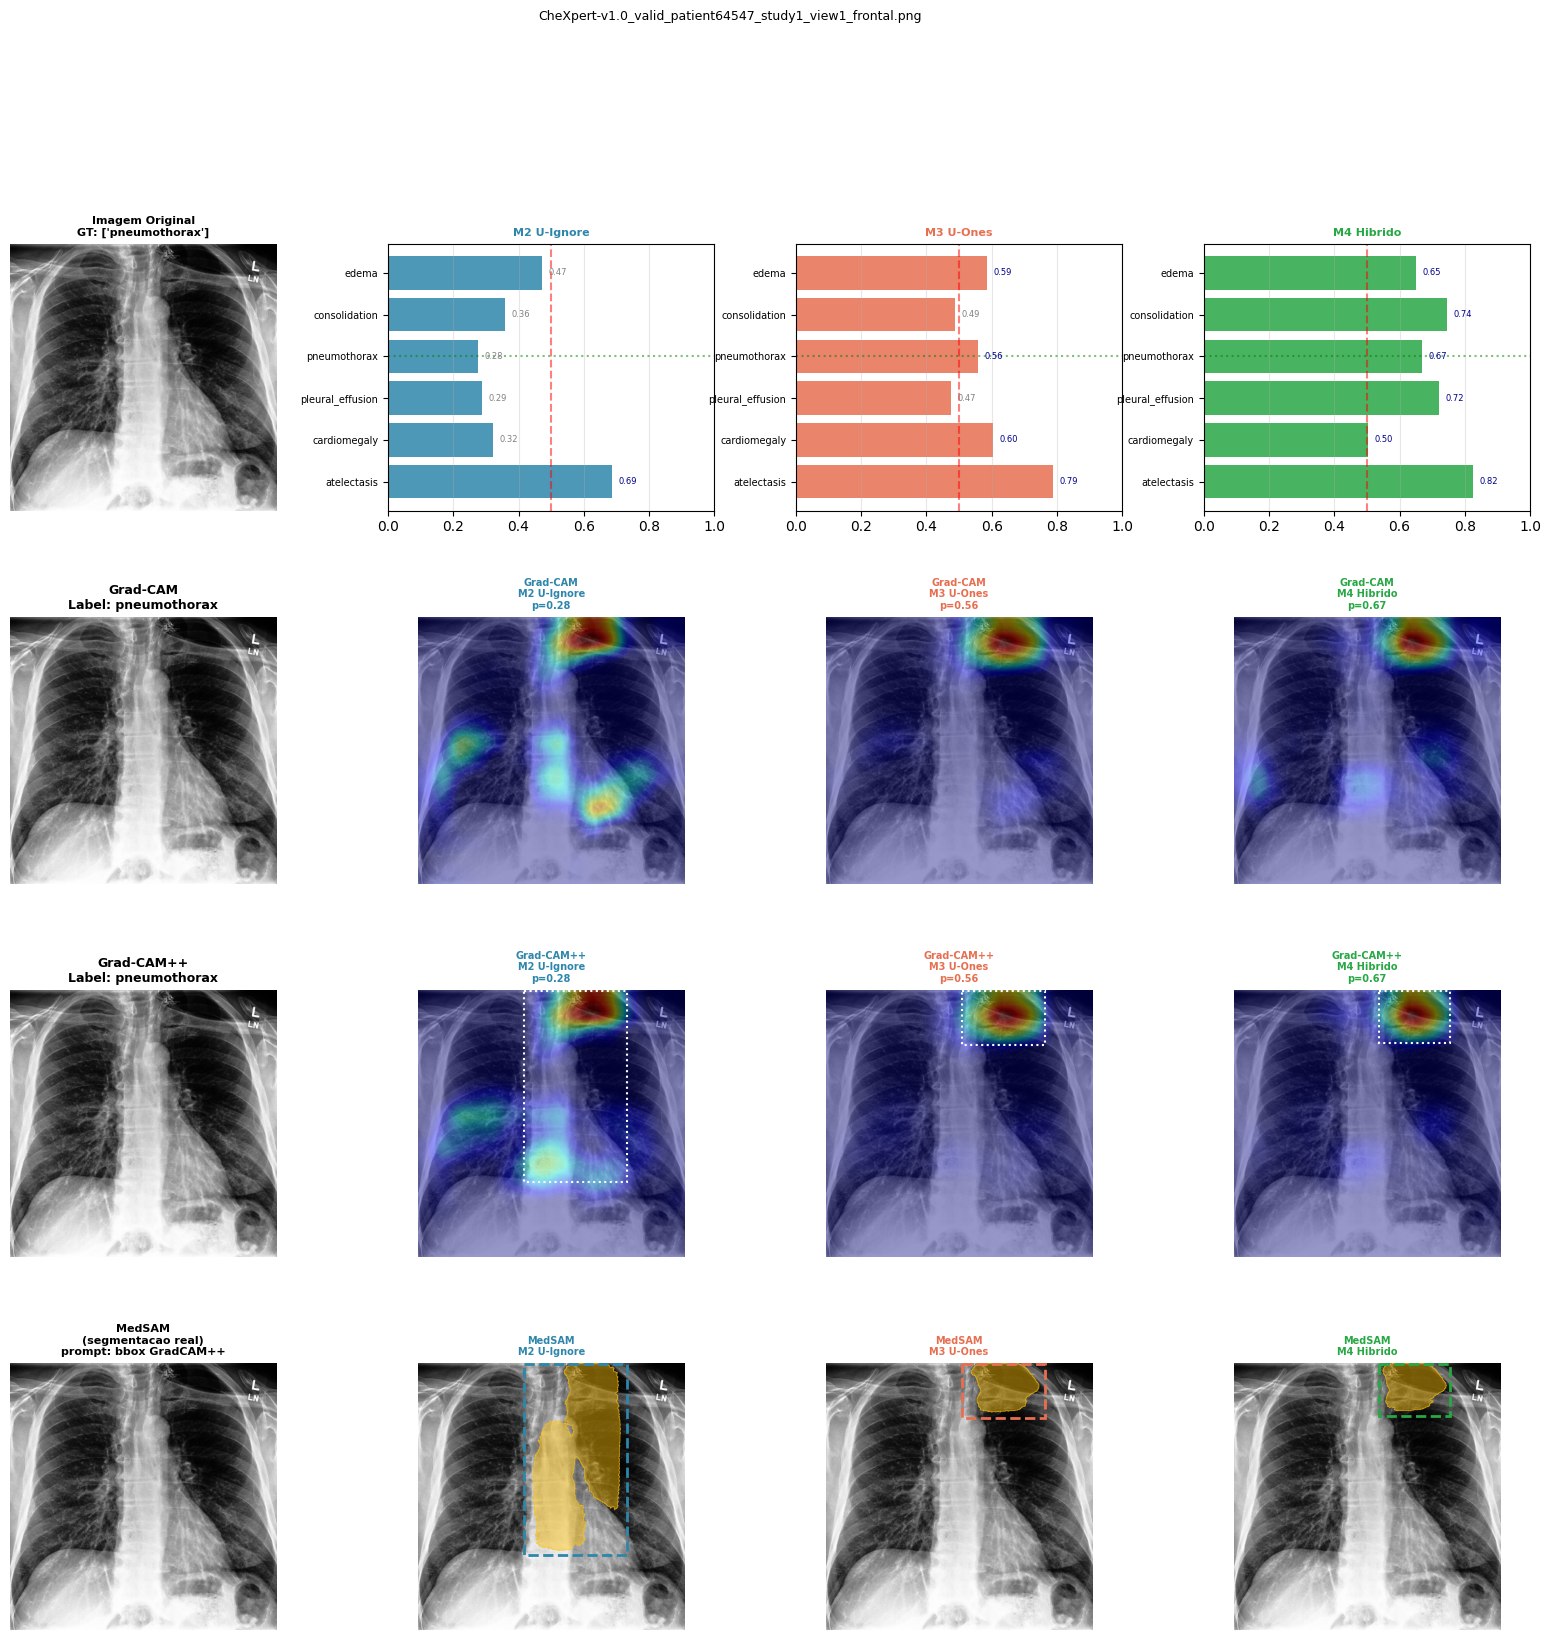

  Label                   M2 U-Ign  M3 U-One  M4 Hibri   GT
  ---------------------------------------------------------
  atelectasis                0.685     0.788     0.824    0
  cardiomegaly               0.323     0.604     0.503    0
  pleural_effusion           0.287     0.474     0.721    0
  pneumothorax               0.276     0.558     0.669   +1
  consolidation              0.358     0.487     0.745    0
  edema                      0.472     0.585     0.652    0

=== Edema — bilateral: diferenca esperada Grad-CAM vs Grad-CAM++ ===


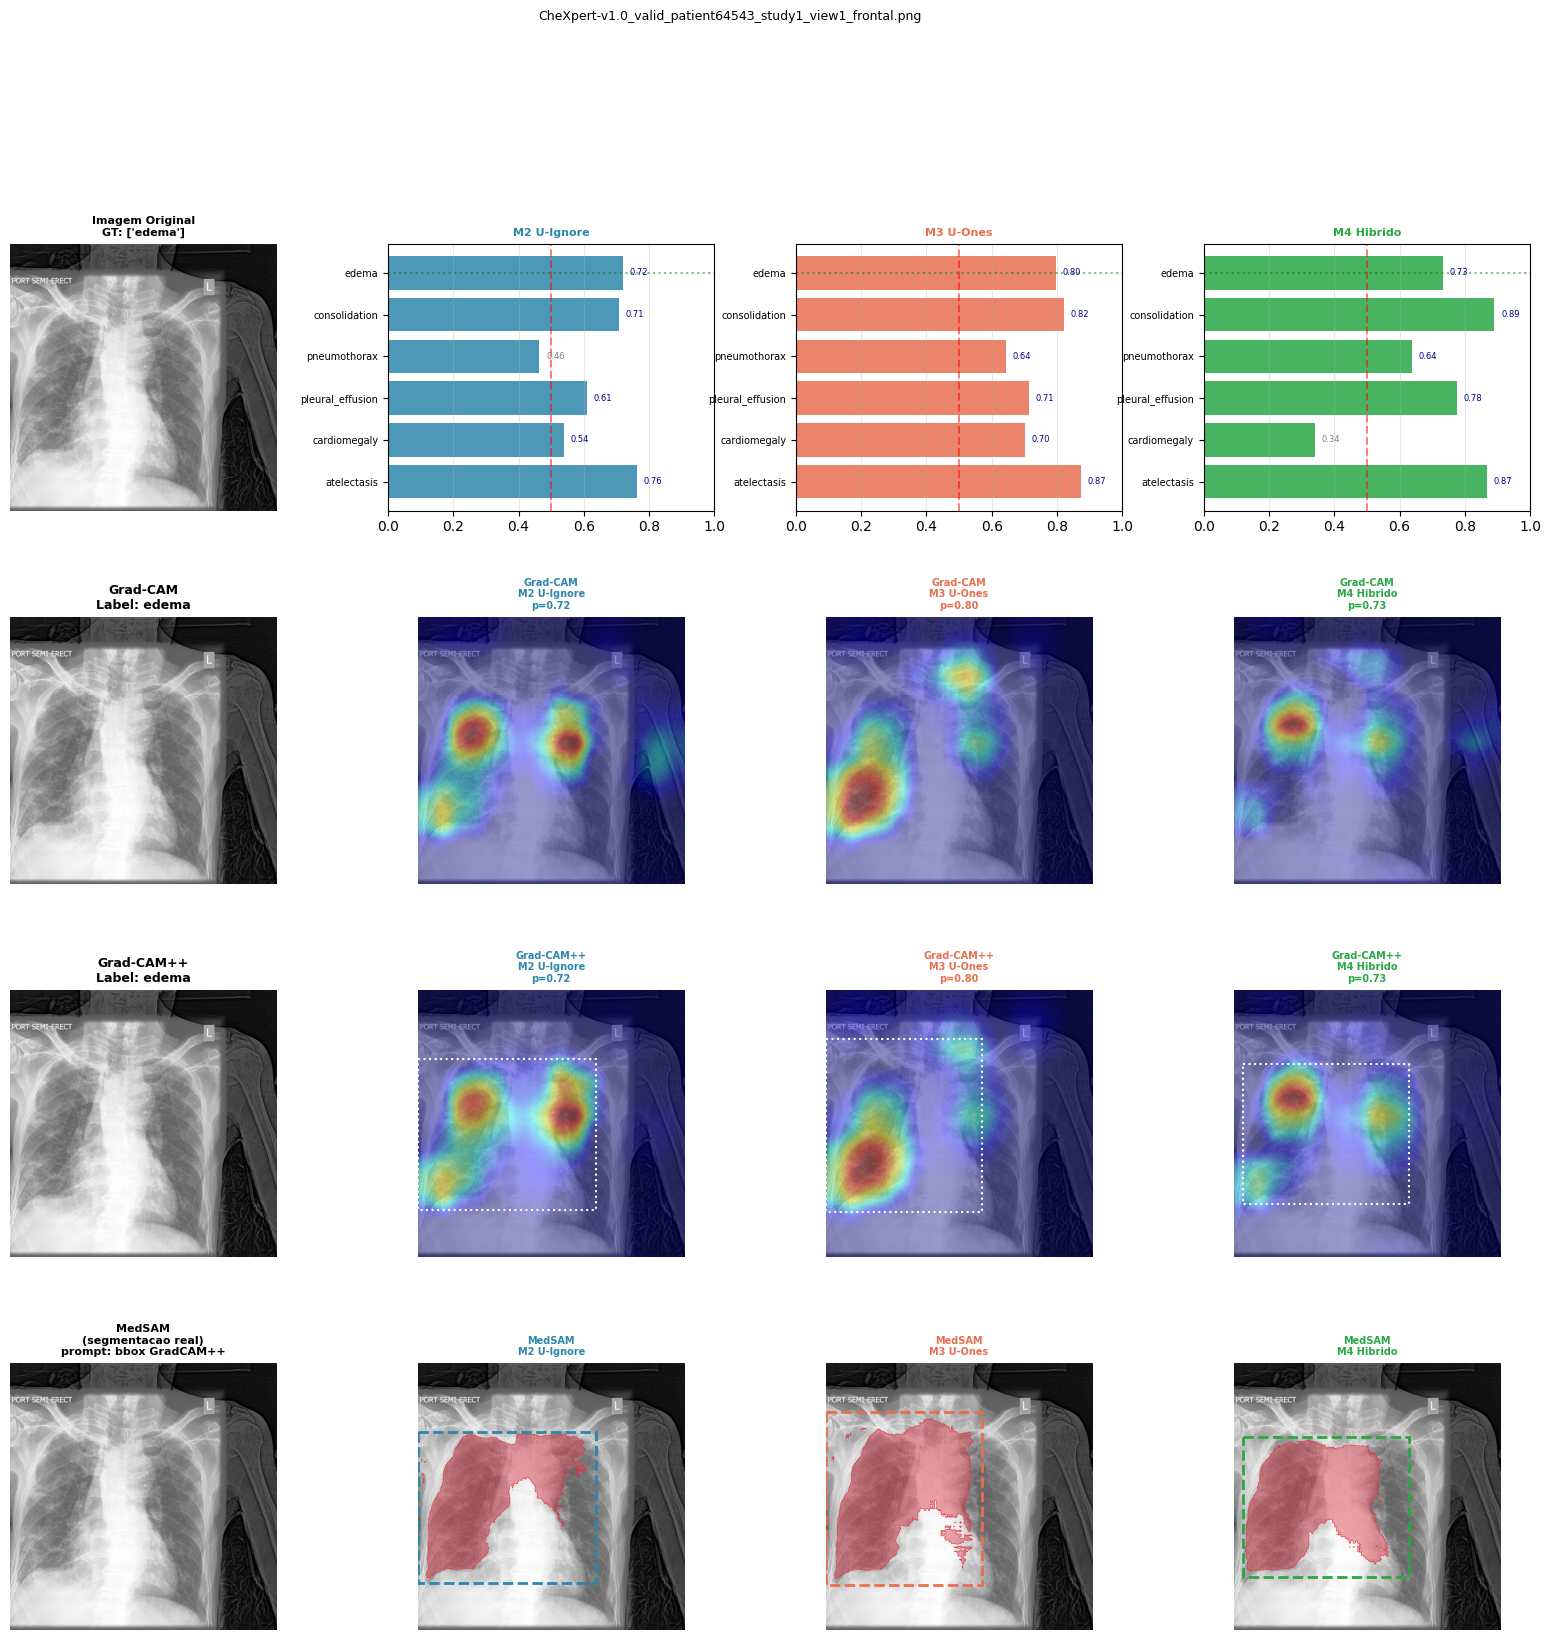

  Label                   M2 U-Ign  M3 U-One  M4 Hibri   GT
  ---------------------------------------------------------
  atelectasis                0.762     0.874     0.869    0
  cardiomegaly               0.539     0.701     0.342    0
  pleural_effusion           0.609     0.713     0.776    0
  pneumothorax               0.464     0.643     0.637    0
  consolidation              0.708     0.820     0.891    0
  edema                      0.719     0.798     0.733   +1

=== Pleural Effusion ===


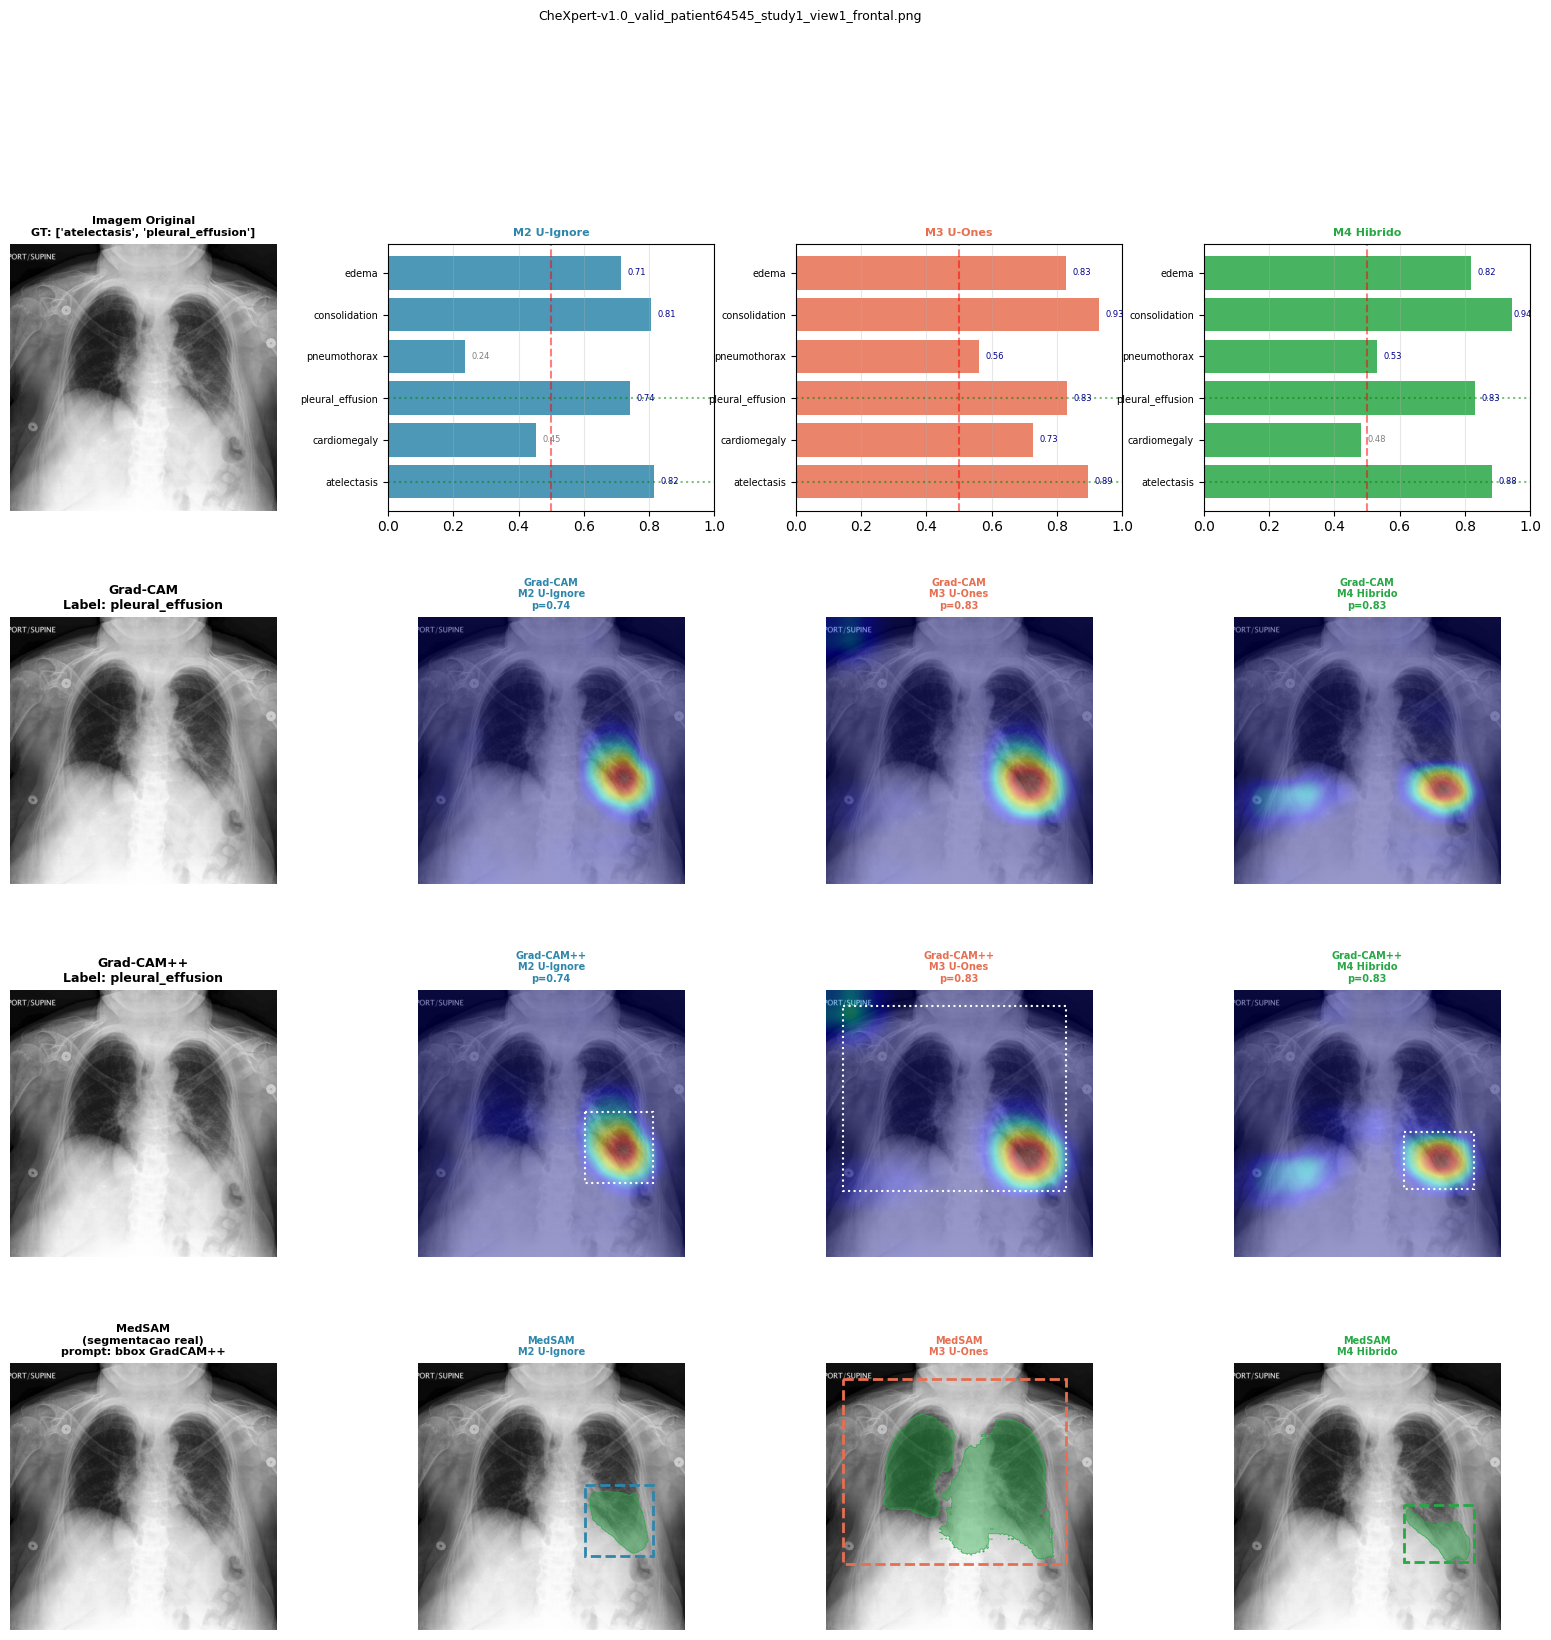

  Label                   M2 U-Ign  M3 U-One  M4 Hibri   GT
  ---------------------------------------------------------
  atelectasis                0.815     0.894     0.884   +1
  cardiomegaly               0.454     0.725     0.483    0
  pleural_effusion           0.743     0.831     0.830   +1
  pneumothorax               0.236     0.562     0.529    0
  consolidation              0.806     0.929     0.944    0
  edema                      0.714     0.829     0.819    0

=== Multi-label ===


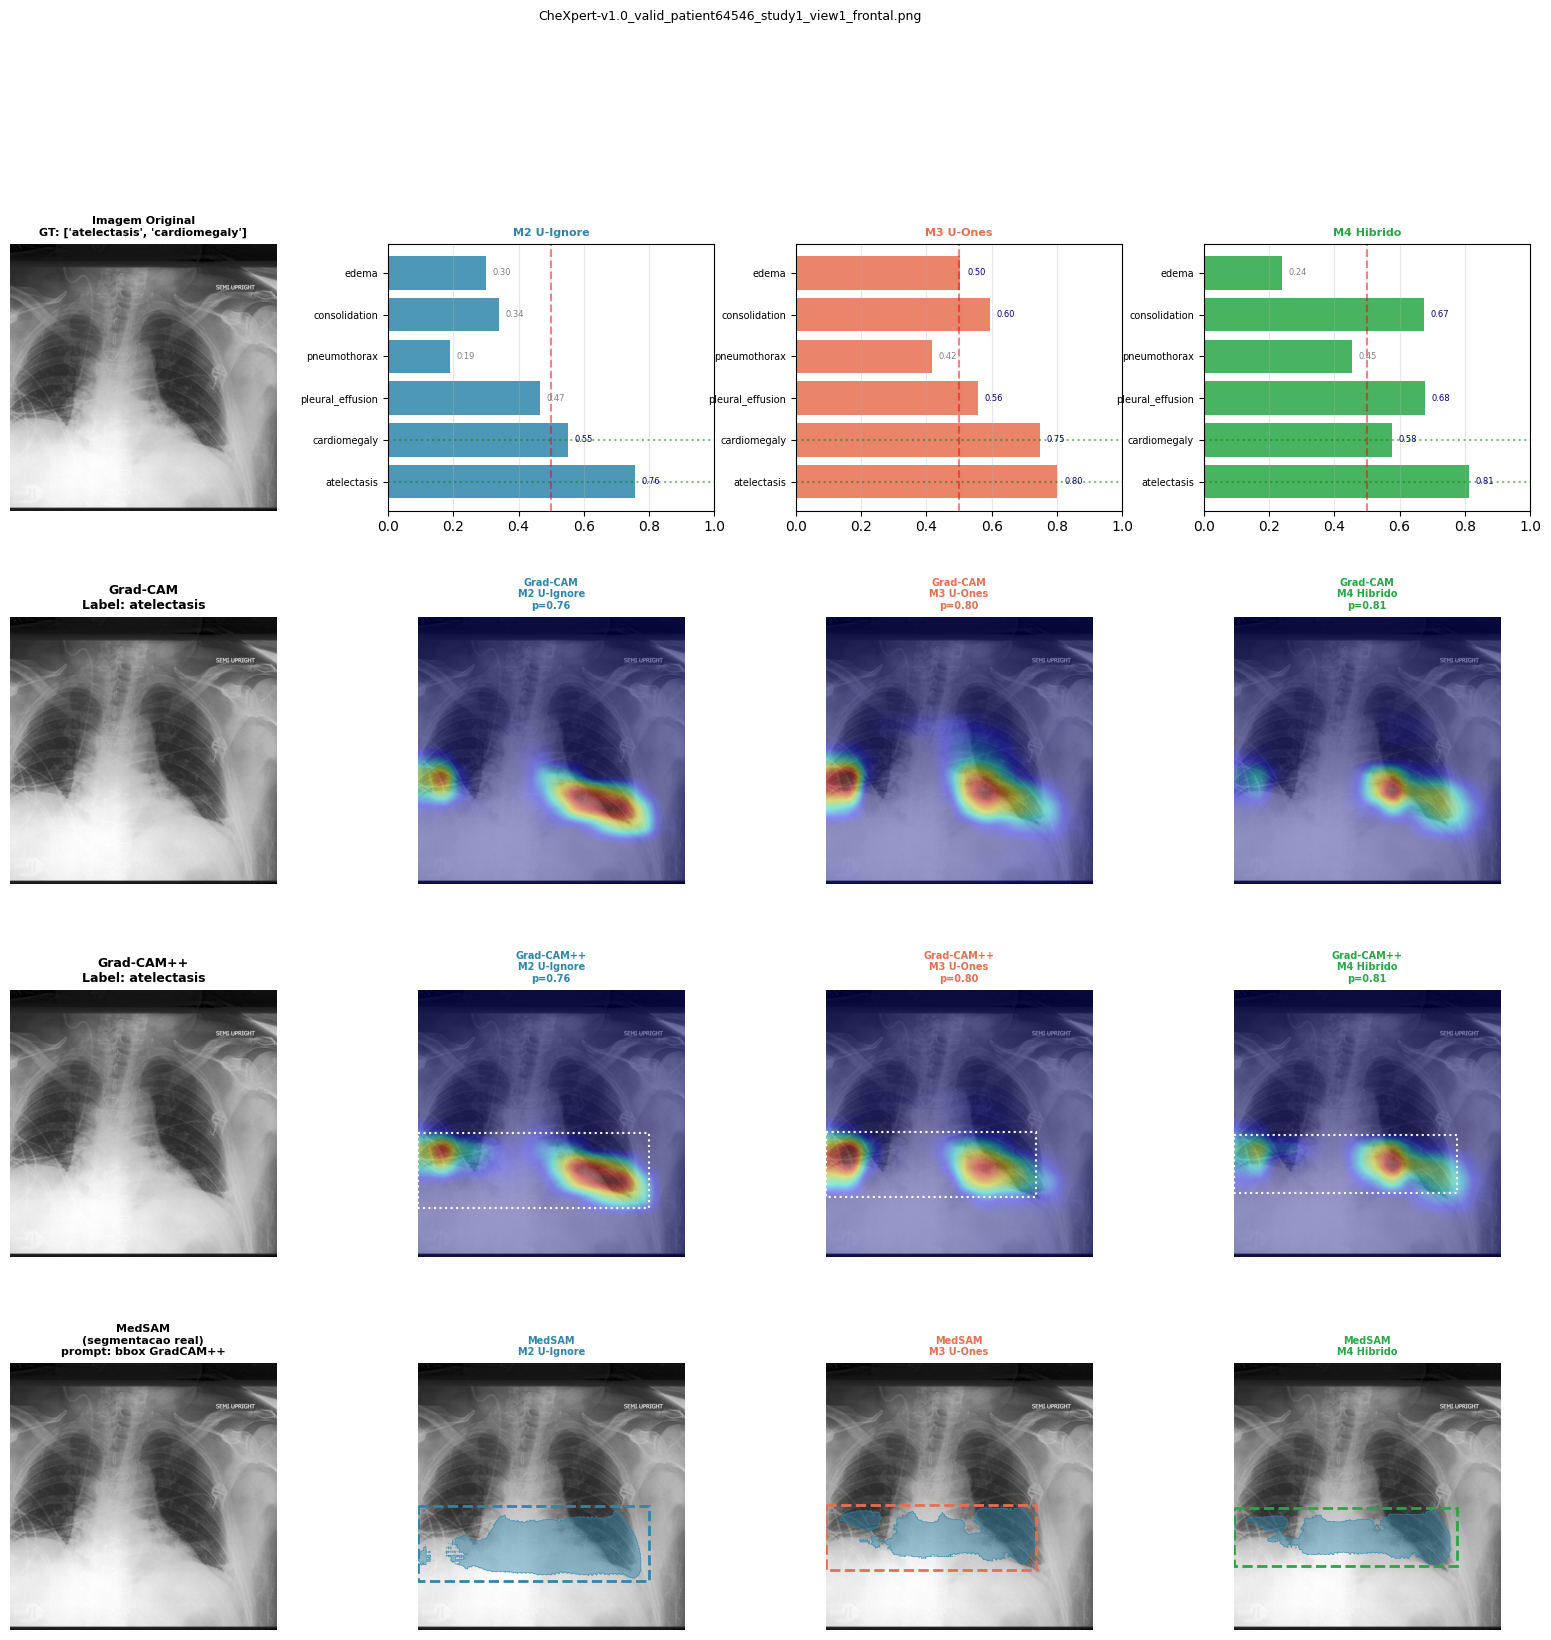

  Label                   M2 U-Ign  M3 U-One  M4 Hibri   GT
  ---------------------------------------------------------
  atelectasis                0.758     0.802     0.814   +1
  cardiomegaly               0.552     0.748     0.576   +1
  pleural_effusion           0.467     0.559     0.677    0
  pneumothorax               0.190     0.416     0.453    0
  consolidation              0.341     0.596     0.674    0
  edema                      0.300     0.504     0.239    0


In [ ]:
df_valid['n_pos'] = df_valid[LABELS].sum(axis=1)
y_true = df_valid[LABELS].values.astype(np.float32)
models_dict = {'M2 U-Ignore':model_m2,'M3 U-Ones':model_m3,'M4 Hibrido':model_m4}

pneumo_idx   = df_valid[df_valid['pneumothorax']==1].index.tolist()
edema_idx    = df_valid[df_valid['edema']==1].index.tolist()
effusion_idx = df_valid[df_valid['pleural_effusion']==1].index.tolist()
multi_idx    = df_valid[df_valid['n_pos']>=2].index.tolist()

if pneumo_idx:
    print('=== Pneumothorax — Grad-CAM | Grad-CAM++ | MedSAM ===')
    idx = pneumo_idx[0]
    gradcam_medsam_panel(df_valid.loc[idx,'img_path'], LABELS,
                          y_true[idx], models_dict,
                          top_label_idx=LABELS.index('pneumothorax'))

if edema_idx:
    print('\n=== Edema — bilateral: diferenca esperada Grad-CAM vs Grad-CAM++ ===')
    idx = edema_idx[0]
    gradcam_medsam_panel(df_valid.loc[idx,'img_path'], LABELS,
                          y_true[idx], models_dict,
                          top_label_idx=LABELS.index('edema'))

if effusion_idx:
    print('\n=== Pleural Effusion ===')
    idx = effusion_idx[0]
    gradcam_medsam_panel(df_valid.loc[idx,'img_path'], LABELS,
                          y_true[idx], models_dict,
                          top_label_idx=LABELS.index('pleural_effusion'))

if len(multi_idx) > 1:
    print('\n=== Multi-label ===')
    idx = multi_idx[1]
    gradcam_medsam_panel(df_valid.loc[idx,'img_path'], LABELS,
                          y_true[idx], models_dict)

## SEÇÃO 9 — Resumo Executivo do Ablation

In [ ]:
print('='*70)
print('ABLATION STUDY FINAL — M1 → M2 → M3 → M4')
print('Classificação Multi-Label CXR | Xception 512×512 | Stanford CheXpert')
print('='*70)

# Trajetória macro
print('\nTrajetória Macro-AUROC:')
traj = [('M1 NIH baseline',          m1_res['macro_auroc'],  'NIH only'),
        ('M2 Crop U-Ignore',          metrics_m2['MACRO']['auroc'], 'Domain transfer + Crop + U-Ignore'),
        ('M3 Crop U-Ones (ε=0.05)',   metrics_m3['MACRO']['auroc'], 'U-Ones irrestrito → colapso Spec'),
        ('M4 Crop Híbrido (ε=0.15)',  metrics_m4['MACRO']['auroc'], 'U-Ones seletivo → recuperação parcial')]
prev = None
for name, val, desc in traj:
    delta = f'{val-prev:+.4f}' if prev else '   —  '
    bar   = '▓' * int((val - 0.75) * 100)
    print(f'  {name:<30} {val:.4f}  {delta}  {bar}')
    prev  = val

print(f'\n{"Label":<22}', end='')
for m in ['M1','M2','M3','M4']: print(f' {m:>7}', end='')
print(f'  {"Best":>5}')
print('-'*58)

for lbl in LABELS:
    vals = [m1_res['per_label_auroc'].get(lbl,0),
            metrics_m2[lbl]['auroc'] or 0,
            metrics_m3[lbl]['auroc'] or 0,
            metrics_m4[lbl]['auroc'] or 0]
    best = max(vals); bmod = ['M1','M2','M3','M4'][vals.index(best)]
    pol = '★' if lbl in UONES_LABELS else ' '
    print(f'{lbl:<22}{pol}', end='')
    for v in vals: print(f' {v:>7.4f}', end='')
    print(f'  {bmod:>5}')

print('-'*58)
macro_vals=[m1_res['macro_auroc'],metrics_m2['MACRO']['auroc'],
            metrics_m3['MACRO']['auroc'],metrics_m4['MACRO']['auroc']]
best_m=max(macro_vals); bmod=['M1','M2','M3','M4'][macro_vals.index(best_m)]
print(f'{"MACRO":<23}', end='')
for v in macro_vals: print(f' {v:>7.4f}', end='')
print(f'  {bmod:>5}')

print(f'\n★ = U-Ones no M4')
print(f'\nDECISÃO FINAL: M2 Crop U-Ignore para publicação')
print(f'  → Macro-AUROC {metrics_m2["MACRO"]["auroc"]:.4f} — melhor configuração geral')
print(f'  → M4 pneumothorax 0.9652 documentado como achado de ablation')
print('='*70)

ABLATION STUDY FINAL — M1 → M2 → M3 → M4
Classificação Multi-Label CXR | Xception 512×512 | Stanford CheXpert

Trajetória Macro-AUROC:
  M1 NIH baseline                0.7697     —    ▓
  M2 Crop U-Ignore               0.8710  +0.1013  ▓▓▓▓▓▓▓▓▓▓▓▓
  M3 Crop U-Ones (ε=0.05)        0.8402  -0.0308  ▓▓▓▓▓▓▓▓▓
  M4 Crop Híbrido (ε=0.15)       0.8546  +0.0144  ▓▓▓▓▓▓▓▓▓▓

Label                       M1      M2      M3      M4   Best
----------------------------------------------------------
atelectasis              0.7044  0.8103  0.7968  0.7895     M2
cardiomegaly             0.8114  0.8254  0.7714  0.8167     M2
pleural_effusion      ★  0.7858  0.8775  0.8684  0.8388     M2
pneumothorax          ★  0.8396  0.9248  0.9314  0.9652     M4
consolidation            0.6493  0.8932  0.8597  0.8521     M2
edema                    0.8277  0.8948  0.8136  0.8653     M2
----------------------------------------------------------
MACRO                    0.7697  0.8710  0.8402  0.8546     M2

★ = U-O

## SEÇÃO 10 — Relatório Final

In [ ]:
!pip install -q anthropic
import anthropic

API_KEY = '<API_KEY>'
client  = anthropic.Anthropic(api_key=API_KEY)

# ── Monta contexto completo do ablation ───────────────────────────────────────
label_lines = []
for lbl in LABELS:
    m1v = m1_res['per_label_auroc'].get(lbl, 0)
    m2v = metrics_m2[lbl]['auroc'] or 0
    m3v = metrics_m3[lbl]['auroc'] or 0
    m4v = metrics_m4[lbl]['auroc'] or 0
    pol = 'U-Ones' if lbl in UONES_LABELS else 'U-Ignore'
    best = max(m1v,m2v,m3v,m4v)
    best_mod = ['M1','M2','M3','M4'][[m1v,m2v,m3v,m4v].index(best)]
    label_lines.append(
        f'  {lbl:<22}[{pol:<8}M4]: M1={m1v:.4f}|M2={m2v:.4f}|M3={m3v:.4f}|M4={m4v:.4f} | Best={best_mod}({best:.4f})'
    )

label_table = '\n'.join(label_lines)
separador   = '─' * 75

# Métricas macro completas
def mac(m, key): return m['MACRO'].get(key) or 0
m2mac = f'AUROC={mac(metrics_m2,"auroc"):.4f}|AUPRC={mac(metrics_m2,"auprc"):.4f}|F1={mac(metrics_m2,"f1"):.4f}|Sens={mac(metrics_m2,"sensitivity"):.4f}|Spec={mac(metrics_m2,"specificity"):.4f}'
m3mac = f'AUROC={mac(metrics_m3,"auroc"):.4f}|AUPRC={mac(metrics_m3,"auprc"):.4f}|F1={mac(metrics_m3,"f1"):.4f}|Sens={mac(metrics_m3,"sensitivity"):.4f}|Spec={mac(metrics_m3,"specificity"):.4f}'
m4mac = f'AUROC={mac(metrics_m4,"auroc"):.4f}|AUPRC={mac(metrics_m4,"auprc"):.4f}|F1={mac(metrics_m4,"f1"):.4f}|Sens={mac(metrics_m4,"sensitivity"):.4f}|Spec={mac(metrics_m4,"specificity"):.4f}'

delong_str = '\n'.join([
    f'  {lbl:<22}: ΔM4-M2={d["a4"]-d["a2"]:+.4f} | z={d["z"]:.3f} | p={d["p"]:.4f} | {d["sig"]}'
    for lbl,d in delong_m4_m2.items()
])

context = f"""
ABLATION STUDY COMPLETO: M1 → M2 → M3 → M4
Tarefa: Classificação multi-label de 6 patologias em CXR (Stanford CheXpert)
Arquitetura: Xception 512×512 | 3 fases de fine-tuning progressivo
Valid set: CheXpert official validation (159 imagens) — mesmo conjunto para M2/M3/M4

DESIGN DO ABLATION (variável por etapa):
  M1 → M2: Domain transfer NIH→CheXpert + Center Crop + U-Ignore
  M2 → M3: Política de labels incertos: U-Ignore → U-Ones irrestrito (ε=0.05)
  M3 → M4: U-Ones seletivo por label (pleural_effusion, pneumothorax) + U-Ignore nos demais (ε=0.15)

RESULTADOS POR LABEL:
{label_table}
  {separador}
  M1  Macro-AUROC: {m1_res['macro_auroc']:.4f}
  M2  Métricas  : {m2mac}
  M3  Métricas  : {m3mac}
  M4  Métricas  : {m4mac}

TESTE DELONG M4 vs M2 (referência):
{delong_str}
  (n=159 — todos ns esperado dado poder estatístico limitado)

ACHADOS PRINCIPAIS DO ABLATION:
  1. M1→M2 (+0.1013): maior contribuição — domain transfer dominante
  2. M2→M3 (-0.0307): U-Ones irrestrito causou colapso de especificidade (Macro-Spec 0.21)
  3. M3→M4 (+0.0144): política híbrida recuperou parcialmente M3 mas não superou M2
  4. Pneumothorax no M4: 0.9652 — melhor resultado individual do estudo (+0.0404 vs M2)
  5. Pleural_effusion no M4: 0.8388 — regressão inesperada (-0.0387 vs M2)
  6. Interferência indireta: atelectasis e consolidation regrediram no M4 apesar de U-Ignore
  7. M2 permanece modelo dominante em Macro-AUROC, AUPRC, F1 e Especificidade
"""

prompt = f"""Você é um pesquisador sênior em visão computacional médica especializado em análise de radiografias de tórax.

Abaixo está o sumário completo do ablation study M1→M4 — o estudo mais abrangente conduzido, cobrindo todas as etapas de design e avaliação de modelos de classificação multi-label de CXR com Xception 512×512 no Stanford CheXpert.

{context}

Produza um relatório técnico final estruturado cobrindo:

1. **Síntese do ablation**: o que cada etapa provou? Quais hipóteses foram confirmadas e quais foram refutadas?
2. **Vencedor por dimensão**: qual modelo é melhor em AUROC, AUPRC, F1, Especificidade, Sensibilidade? Há conflito entre as dimensões?
3. **Achado mais importante**: o pneumothorax 0.9652 no M4 e sua interpretação — é clinicamente relevante apesar do Macro-AUROC inferior?
4. **Mecanismo de interferência indireta**: por que labels U-Ignore regrediram no M4 se a política era protegê-los?
5. **Modelo para publicação e benchmark**: M2 ou M4? Como reportar os dois no paper sem confundir o leitor?
6. **Comparação com literatura**: onde este ablation se posiciona em relação a CheXNet, DenseNet-121 e outros benchmarks publicados no CheXpert?
7. **Limitações metodológicas do estudo**: o que n=159, ausência de cross-validation e o design sequencial do ablation não podem garantir?
8. **Agenda para trabalhos futuros**: quais são as 3 extensões mais promissoras com maior potencial de impacto?

Seja direto, técnico e cite os números exatos. Responda em português brasileiro."""

print('Enviando para Claude API...')
t0 = time.time()
message = client.messages.create(
    model='claude-sonnet-4-6', max_tokens=8192,
    messages=[{'role':'user','content':prompt}]
)
relatorio = message.content[0].text
elapsed   = time.time() - t0
print(f'Resposta em {elapsed:.1f}s | {message.usage.input_tokens} in | {message.usage.output_tokens} out')

print('\n' + '='*65)
print('RELATÓRIO FINAL DO ABLATION — Claude Sonnet')
print('='*65)
print(relatorio)

report_path = f'{OUT_DIR}/relatorio_final_ablation_claude.txt'
with open(report_path, 'w', encoding='utf-8') as f:
    f.write(context + '\n\n' + '='*65 + '\nRELATÓRIO CLAUDE\n' + '='*65 + '\n\n' + relatorio)
print(f'\nRelatório salvo: {report_path}')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 833.0/833.0 kB 47.2 MB/s eta 0:00:00
Enviando para Claude API...
Resposta em 120.5s | 1789 in | 6208 out

RELATÓRIO FINAL DO ABLATION — Claude Sonnet
# Relatório Técnico Final: Ablation Study M1→M4
## Classificação Multi-label de CXR com Xception 512×512 no Stanford CheXpert

---

## 1. Síntese do Ablation: O Que Cada Etapa Provou

### M1→M2 (+0.1013 Macro-AUROC): Domain Transfer é o Fator Dominante

A transição NIH ChestX-ray14 → CheXpert, combinada com center crop e política U-Ignore, produziu o maior salto isolado do estudo: de 0.7697 para 0.8710 em Macro-AUROC. **Hipótese confirmada**: diferenças de distribuição entre domínios (NIH vs. CheXpert) constituíam o principal gargalo de desempenho. Os ganhos foram consistentes em todos os seis labels — atelectasis (+0.1059), consolidation (+0.2439), pneumothorax (+0.0852) — confirmando que o problema não era arquitetural, mas de domain mismatch. O center crop eliminou artefatos de borda que cont